<a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/Proyecto_Aula_EDA_OUTLIERS_PROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>Proyecto_Aula_EDA_OUTLIERS_PROCESSING</strong></span>
---
**Pregunta de investigación:** ¿Qué factores afectan la adopción de vehículos eléctricos en una nación?  
**Dataset:** `ev_vs_petrol_dataset_v3` — Kaggle (Aryan Mishra, 2024)  
**Autor:** Juan Manuel Vera  
**Programa:** Ingeniería de Sistemas — Universidad de Antioquia  
**Curso:** Fundamentos de Ciencia de Datos

---
Este notebook consolida el ciclo analítico completo del proyecto de aula, organizado en cuatro partes:

| Parte | Contenido |
|-------|-----------|
| **1** | Definición del problema, descripción del dataset y visualizaciones exploratorias básicas |
| **2** | EDA bivariado y multivariado: multicolinealidad entre predictores y relevancia respecto al objetivo |
| **3** | Detección y tratamiento de datos atípicos (métodos gráficos, estadísticos y de ML) |
| **4** | Transformación de variables y escalamiento para preprocesamiento |


## ⚙️ Preparación del entorno y carga de datos
Las siguientes librerías y la carga del dataset son compartidas por todas las partes del proyecto.


In [1]:
# ── Librerías ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import os, shutil

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13, "axes.labelsize": 11})

# ── Carga de datos ────────────────────────────────────────────────
import kagglehub
ev_vs_petrol = kagglehub.dataset_download('aryanmdev/will-evs-replace-petrol-cars')

carpeta_destino = 'data'
os.makedirs(carpeta_destino, exist_ok=True)
shutil.copy(os.path.join(ev_vs_petrol, 'ev_vs_petrol_dataset_v3.csv'),
            os.path.join(carpeta_destino, 'ev_vs_petrol_dataset_v3.csv'))

df = pd.read_csv("data/ev_vs_petrol_dataset_v3.csv")
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")


100%|██████████| 38.6k/38.6k [00:00<00:00, 2.88MB/s]

Extracting files...
Dataset cargado: 1200 filas × 22 columnas


In [2]:
print("Vista previa de los datos disponibles:\n", df.head(5))

Vista previa de los datos disponibles:
      country   region  year vehicle_segment powertrain_type  ev_sales  \
0  Australia  Oceania  2010      commercial             ICE         5   
1  Australia  Oceania  2010     mass_market             ICE        57   
2  Australia  Oceania  2010         premium             ICE        37   
3  Australia  Oceania  2011      commercial             ICE        11   
4  Australia  Oceania  2011     mass_market             ICE       129   

   petrol_car_sales  diesel_car_sales  total_vehicle_sales  ev_market_share  \
0             92877             61921               154803             0.00   
1            535933             73089               609079             0.01   
2            235282             20462               255781             0.01   
3             98092             65395               163498             0.01   
4            569679             77684               647492             0.02   

   ...  avg_ev_range_km  fuel_price_usd_per_li

### 🗂️ Nota sobre la estructura del dataset

El dataset contiene **3 filas por combinación país-año**, correspondientes a los segmentos vehiculares: `commercial`, `mass_market` y `premium`. A lo largo del proyecto se trabaja en dos niveles de análisis:

- **`df`** — dataset completo (1 200 filas): usado cuando el análisis involucra diferencias entre segmentos.
- **`df_pais`** — agregado por país-año (400 filas): usado para variables macroeconómicas e indicadores de infraestructura que son idénticos en los tres segmentos del mismo país-año, evitando triplicar artificialmente esas observaciones.


In [3]:
# Dataset agregado a nivel país-año
vars_macro = [
    'ev_market_share', 'charging_stations', 'fast_chargers_share', 'avg_ev_range_km',
    'fuel_price_usd_per_liter', 'electricity_price_usd_per_kwh', 'gdp_per_capita',
    'urban_population_percent', 'co2_emissions_transport_mt', 'ev_subsidy_usd',
    'emission_regulation_score', 'ev_growth_rate_yoy', 'is_ev_dominant'
]
df_pais = df.groupby(['country', 'region', 'year'])[vars_macro].mean().reset_index()
print(f"df_pais: {df_pais.shape[0]} filas × {df_pais.shape[1]} columnas")


df_pais: 400 filas × 16 columnas


---
# <span style="color:#2F749F;"><strong>Parte 1: Definición de la base de datos y visualización básica</strong></span>


## <span style="color:Blue;"><strong>1. Introducción</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>1. Breve presentación del problema o pregunta de investigación.</b>  
</div>

¿Qué factores afectan la adopción de vehiculos electricos en una nación?

<br>
<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b> 2. Contexto:</b>  ¿por qué es relevante este problema?
</div>

Comprender los factores que influyen en la adopción de vehículos eléctricos (EV) y analizar cómo se distribuyen estos datos entre países y a lo largo del tiempo es fundamental para interpretar de manera objetiva un proceso de transformación tecnológica con implicaciones **económicas, energéticas y ambientales** complejas. Más allá de posturas a favor o en contra de la movilidad eléctrica; considerando que también existen impactos asociados para cada nación que permiten entender patrones reales del mercado y evitar conclusiones basadas únicamente en percepciones o discursos ideológicos. Estudiar cómo estos factores se relacionan entre sí ayuda a identificar **tendencias, correlaciones y diferencias estructurales entre naciones**, aportando una base empírica sólida para la toma de decisiones, la investigación académica y un debate informado sobre el futuro del transporte.

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b> 3. Relación entre el problema y la base de datos seleccionada. </b>  
</div>

Para examinar esta problemática, se emplea el conjunto de datos **ev_vs_petrol_dataset_v3**, el cual integra información comparativa por país y año sobre el mercado de vehículos eléctricos y de combustión interna. A diferencia de un enfoque descriptivo, esta base permite analizar el fenómeno desde una perspectiva estructural, ya que combina variables de adopción como la **participación de mercado de los EV (`ev_market_share`)** y las **ventas de vehículos eléctricos (`ev_sales`)**; así como factores potencialmente explicativos como el **PIB per cápita**, los **subsidios gubernamentales (`ev_subsidy_usd`)**, los **precios del combustible y la electricidad**, la **infraestructura de carga (`charging_stations`)** y el **nivel de regulación ambiental (`emission_regulation_score`)**. Esta integración de dimensiones económicas, energéticas y regulatorias nos permite observar diferencias entre naciones, además de explorar cómo interactúan estos elementos en la configuración de patrones de adopción de estos vehiculos.

## <span style="color:Blue;"><strong>2. Descripción de la base de datos</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">

<b>- Número de registros y variables.</b><br>
Cantidad total de observaciones (país-año) y número de variables incluidas en el dataset, lo que permite dimensionar el alcance del análisis sobre la adopción de vehículos eléctricos.

<b>- Descripción de las variables más relevantes.</b><br>
Se destacan variables relacionadas con la <strong>adopción de vehículos eléctricos</strong> (por ejemplo, participación de mercado y ventas de EV) y posibles factores explicativos como <strong>PIB per cápita, subsidios, precios de energía, infraestructura de carga y regulación ambiental</strong>.

<b>- Tipos de datos.</b><br>
Identificación de variables <strong>numéricas</strong> (ventas, precios, ingresos), <strong>categóricas</strong> (país), y <strong>temporales</strong> (año), lo cual es clave para definir el tipo de análisis estadístico o modelo a aplicar.

</div>

In [4]:
# Visualizar una pequeña muestra de los datos
df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [5]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 1200
Número de variables: 22


In [6]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
int64      10
float64     8
object      4
Name: count, dtype: int64


In [7]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))


🔹 Variables categóricas:
- country
- region
- vehicle_segment
- powertrain_type

🔸 Variables numéricas:
- year
- ev_sales
- petrol_car_sales
- diesel_car_sales
- total_vehicle_sales
- ev_market_share
- charging_stations
- fast_chargers_share
- avg_ev_range_km
- fuel_price_usd_per_liter
- electricity_price_usd_per_kwh
- gdp_per_capita
- urban_population_percent
- co2_emissions_transport_mt
- ev_subsidy_usd
- emission_regulation_score
- ev_growth_rate_yoy
- is_ev_dominant


In [8]:
# Descripción general
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
              year      ev_sales  petrol_car_sales  diesel_car_sales  \
count  1200.000000  1.200000e+03      1.200000e+03      1.200000e+03   
mean   2017.500000  6.360236e+04      7.733063e+05      1.409369e+05   
std       4.611694  4.079506e+05      1.756934e+06      2.913472e+05   
min    2010.000000  5.000000e+00      1.727000e+03      1.500000e+02   
25%    2013.750000  2.002500e+02      8.870500e+04      1.951075e+04   
50%    2017.500000  2.731500e+03      2.294785e+05      5.136100e+04   
75%    2021.250000  1.990500e+04      6.385320e+05      1.111910e+05   
max    2025.000000  7.670056e+06      1.477369e+07      2.014595e+06   

       total_vehicle_sales  ev_market_share  charging_stations  \
count         1.200000e+03      1200.000000       1.200000e+03   
mean          9.778455e+05         6.327992       5.693898e+04   
std           2.211799e+06        13.231723       3.359383e+05   
min           1.748000e+04         0.000000       

## <span style="color:Blue;"><strong>3. Análisis inicial de las variables</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">

<b>- Identificación de las variables clave.</b><br>
Selección de la variable principal que mide la <strong>adopción de vehículos eléctricos</strong> y de los posibles factores explicativos relacionados.

<b>- Conteo de valores, tipos de datos y valores faltantes.</b><br>
Revisión del número total de observaciones por variable, verificación de <strong>tipos de datos</strong> (numéricos, categóricos, temporales) y detección de <strong>valores faltantes o inconsistencias</strong>, con el fin de asegurar la calidad de los datos antes de realizar análisis estadísticos o modelos explicativos.

</div>

In [9]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


In [10]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
total_vehicle_sales              1200
petrol_car_sales                 1199
diesel_car_sales                 1194
ev_growth_rate_yoy               1008
ev_sales                         1005
ev_market_share                   569
gdp_per_capita                    399
charging_stations                 380
co2_emissions_transport_mt        351
emission_regulation_score         315
ev_subsidy_usd                    294
urban_population_percent          244
avg_ev_range_km                   239
fuel_price_usd_per_liter          237
fast_chargers_share               219
electricity_price_usd_per_kwh     197
country                            25
year                               16
region                              5
vehicle_segment                     3
powertrain_type                     2
is_ev_dominant                      2
dtype: int64


## Variables más importantes a analizar

Para responder la pregunta **¿Qué factores afectan la adopción de vehículos eléctricos en una nación?**, es necesario distinguir entre la **variable que mide la adopción** y las **variables que pueden explicarla**. A partir de la descripción estadística disponible y complementando con la definición de cada variable, podemos hacer un analisis previo de las más importantes:



### 1. Variable principal de adopción en una nación

- **`ev_market_share`**  
  Es la variable más adecuada para medir la adopción, ya que representa la proporción de vehículos eléctricos dentro del total de ventas. Su amplia dispersión (desde 0% hasta 95%) indica diferencias significativas entre países, lo que permite realizar análisis comparativos robustos.

- **`ev_sales`** y **`ev_growth_rate_yoy`**  
  Complementan el análisis al mostrar el volumen absoluto de ventas y la dinámica de crecimiento. Sin embargo, para comparaciones entre países, la participación de mercado resulta más adecuada que los valores absolutos.



### 2. Factores económicos

- **`gdp_per_capita`**  
  Presenta una alta variabilidad, lo que permite analizar si la adopción depende del nivel de desarrollo económico de una nación.

- **`ev_subsidy_usd`**  
  Refleja la intervención directa del Estado mediante incentivos económicos. El hecho de que muchos países registren valores cero permite comparar contextos con y sin subsidios.

Estas variables permiten evaluar si la adopción está asociada principalmente a la capacidad económica o a políticas públicas de incentivo.


### 3. Factores energéticos

- **`fuel_price_usd_per_liter`**
- **`electricity_price_usd_per_kwh`**

El diferencial entre el costo del combustible y el de la electricidad puede influir en la decisión de compra. La variabilidad observada en ambas variables permite analizar la sensibilidad del mercado a los precios energéticos.



### 4. Infraestructura y desarrollo tecnológico

- **`charging_stations`**  
  La gran dispersión en esta variable sugiere que la disponibilidad de infraestructura, la disponibilidad de puntos de carga podría ser un factor determinante en la adopción.

- **`fast_chargers_share`**  
  Indica la calidad y eficiencia de la red de carga, los puntos de carga rapida usualmente ubicados en puntos claves como centros comerciales, mercados o parques son un beneficio directo para los vehiculos electricos.

- **`avg_ev_range_km`**  
  Representa la autonomía en kilometros,el avance tecnológico en la autonomía de los vehículos eléctricos y puede influir en la percepción de viabilidad del EV.


### 5. Factores regulatorios y estructurales

- **`emission_regulation_score`**  
  Permite analizar si una mayor presión regulatoria ambiental se asocia con mayores niveles de adopción.

- **`urban_population_percent`**  
  Países con mayor urbanización podrían facilitar la transición hacia la movilidad eléctrica debido a características propias de los entornos urbanos.



### Conclusión

Para un análisis integral, la variable central debería ser **`ev_market_share`**, explicada por un conjunto de factores económicos (`gdp_per_capita`, `ev_subsidy_usd`), energéticos (`fuel_price_usd_per_liter`, `electricity_price_usd_per_kwh`), de infraestructura (`charging_stations`, `fast_chargers_share`), regulatorios (`emission_regulation_score`) y estructurales (`urban_population_percent`). Esta combinación permite evaluar de manera equilibrada las distintas dimensiones que pueden influir en la adopción de vehículos eléctricos a nivel nacional.

In [11]:
# Variables más importantes (selección manual según la pregunta de investigación)
variables_clave = [
    'ev_market_share',          # Variable dependiente (adopción)
    'gdp_per_capita',           # Factor económico
    'ev_subsidy_usd',           # Incentivos gubernamentales
    'fuel_price_usd_per_liter', # Precio del combustible
    'electricity_price_usd_per_kwh', # Precio de electricidad
    'charging_stations',        # Infraestructura
    'fast_chargers_share',      # Calidad de infraestructura
    'emission_regulation_score',# Regulación ambiental
    'urban_population_percent'  # Factor estructural
]

print("\nVista rápida de variables clave:")
print(df[variables_clave].head())

print("\nEstadísticas descriptivas de variables clave:")
print(df[variables_clave].describe())


Vista rápida de variables clave:
   ev_market_share  gdp_per_capita  ev_subsidy_usd  fuel_price_usd_per_liter  \
0             0.00           51977               0                      1.09   
1             0.01           51977               0                      1.09   
2             0.01           51977               0                      1.09   
3             0.01           52807               0                      1.09   
4             0.02           52807               0                      1.09   

   electricity_price_usd_per_kwh  charging_stations  fast_chargers_share  \
0                          0.149                  0                  0.0   
1                          0.149                  0                  0.0   
2                          0.149                  0                  0.0   
3                          0.163                105                  1.5   
4                          0.163                105                  1.5   

   emission_regulation_score

## <span style="color:Blue;"><strong>4. Visualizaciones exploratorias básicas</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">

<b>- Gráficos de dispersión para analizar relaciones clave.</b><br>
Construcción de gráficos de dispersión entre la variable de adopción (<code>ev_market_share</code>) y posibles factores explicativos como <code>gdp_per_capita</code>, <code>ev_subsidy_usd</code>, <code>fuel_price_usd_per_liter</code>, <code>electricity_price_usd_per_kwh</code>, <code>charging_stations</code> y <code>emission_regulation_score</code>, con el fin de identificar patrones, tendencias o posibles correlaciones.

<b>- Breve interpretación de los resultados.</b><br>
Análisis preliminar de las gráficas para detectar relaciones lineales o no lineales, concentración de valores, dispersión entre países y posibles comportamientos atípicos que puedan influir en el análisis posterior.

<b>- Histogramas y gráficos de barras.</b><br>
Uso de histogramas para observar la distribución de variables numéricas (por ejemplo, <code>ev_market_share</code>, <code>gdp_per_capita</code>, <code>charging_stations</code>) y gráficos de barras para variables categóricas como <code>country</code> o <code>is_ev_dominant</code>, con el objetivo de comprender la forma de la distribución y la presencia de asimetrías o concentraciones relevantes.

</div>


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

VAR_Y = "ev_market_share"
VAR_YEAR = "year"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas en df: {missing}. Revisa df.columns.")
    return True

def clean_cols(df, cols):
    d = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
    return d

def boxplot_por_anio(df, col, titulo, ylabel, use_log1p=False):
    require_cols(df, [VAR_YEAR, col])
    d = clean_cols(df, [VAR_YEAR, col]).copy()
    d[VAR_YEAR] = d[VAR_YEAR].astype(int)

    years = sorted(d[VAR_YEAR].unique())
    data = []
    for y in years:
        s = d.loc[d[VAR_YEAR] == y, col]
        if use_log1p:
            s = np.log1p(s)
        data.append(s.values)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.boxplot(data, tick_labels=years, showfliers=True)
    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

def hist_por_anio(df, col, titulo, xlabel, bins=25, max_cols=4):
    """
    Histograma por año en un grid. Útil para ver cómo cambia la distribución con el tiempo.
    """
    require_cols(df, [VAR_YEAR, col])
    d = clean_cols(df, [VAR_YEAR, col]).copy()
    d[VAR_YEAR] = d[VAR_YEAR].astype(int)
    years = sorted(d[VAR_YEAR].unique())

    n = len(years)
    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows))
    axes = np.array(axes).reshape(-1)

    for i, y in enumerate(years):
        ax = axes[i]
        s = d.loc[d[VAR_YEAR] == y, col]
        ax.hist(s, bins=bins)
        ax.set_title(f"{y}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")

    # Apagar ejes sobrantes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

def scatter_color_por_anio(df, xcol, ycol, titulo, xlabel, ylabel, x_log1p=False):
    require_cols(df, [VAR_YEAR, xcol, ycol])
    d = clean_cols(df, [VAR_YEAR, xcol, ycol]).copy()
    d[VAR_YEAR] = d[VAR_YEAR].astype(int)

    x = d[xcol].values
    if x_log1p:
        x = np.log1p(x)

    y = d[ycol].values
    c = d[VAR_YEAR].values

    fig, ax = plt.subplots(figsize=(11, 6))
    sc = ax.scatter(x, y, c=c, alpha=0.75)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Año")
    plt.tight_layout()
    plt.show()

def scatter_promedio_por_anio(df, xcol, ycol, titulo, xlabel, ylabel, x_log1p=False):
    """
    Scatter usando el promedio por año (promedio sobre países) para ver relación en el tiempo
    sin ruido de escala país-año.
    """
    require_cols(df, [VAR_YEAR, xcol, ycol])
    d = clean_cols(df, [VAR_YEAR, xcol, ycol]).copy()
    d[VAR_YEAR] = d[VAR_YEAR].astype(int)

    g = d.groupby(VAR_YEAR)[[xcol, ycol]].mean().sort_index()
    x = g[xcol].values
    if x_log1p:
        x = np.log1p(x)
    y = g[ycol].values

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(g.index.values, y, marker="o")
    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def line_promedio_por_anio(df, col, titulo, ylabel):
    require_cols(df, [VAR_YEAR, col])
    d = clean_cols(df, [VAR_YEAR, col]).copy()
    d[VAR_YEAR] = d[VAR_YEAR].astype(int)
    g = d.groupby(VAR_YEAR)[col].mean().sort_index()

    fig, ax = plt.subplots()
    ax.plot(g.index, g.values, marker="o")
    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()


#4.1 Variables por año
En estas variables no me interesa conocer la afectación por pais de momento, solo su crecimiento

## 4.1.1 Adopción EV (ev_market_share)


[1.1.A] Tendencia temporal promedio: Adopción de EV


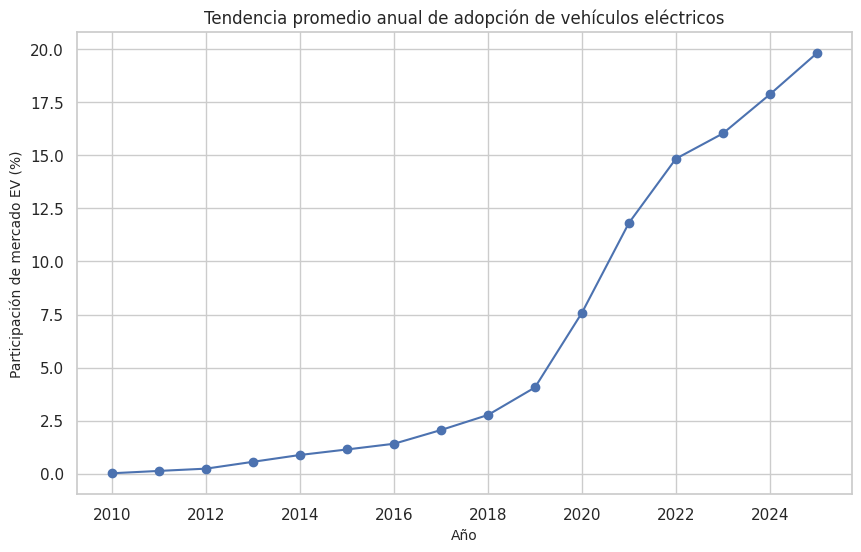

In [13]:
print("\n[1.1.A] Tendencia temporal promedio: Adopción de EV")

promedio_anual = df.groupby("year")["ev_market_share"].mean()

plt.figure(figsize=(10,6))
plt.plot(promedio_anual.index, promedio_anual.values, marker="o")
plt.title("Tendencia promedio anual de adopción de vehículos eléctricos")
plt.xlabel("Año")
plt.ylabel("Participación de mercado EV (%)")
plt.show()

La gráfica muestra una tendencia creciente sostenida en la adopción promedio de vehículos eléctricos entre 2010 y 2025. El crecimiento es moderado hasta 2017, pero a partir de 2018 se observa una aceleración clara, especialmente entre 2020 y 2022, lo que sugiere un punto de inflexión en la transición hacia la movilidad eléctrica. Esto indica que la adopción no ha sido lineal, sino que ha respondido a factores que impulsaron una expansión más rápida en los últimos años.


[1.1.B] Distribución por año: Adopción de EV


/tmp/ipykernel_11531/811476164.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


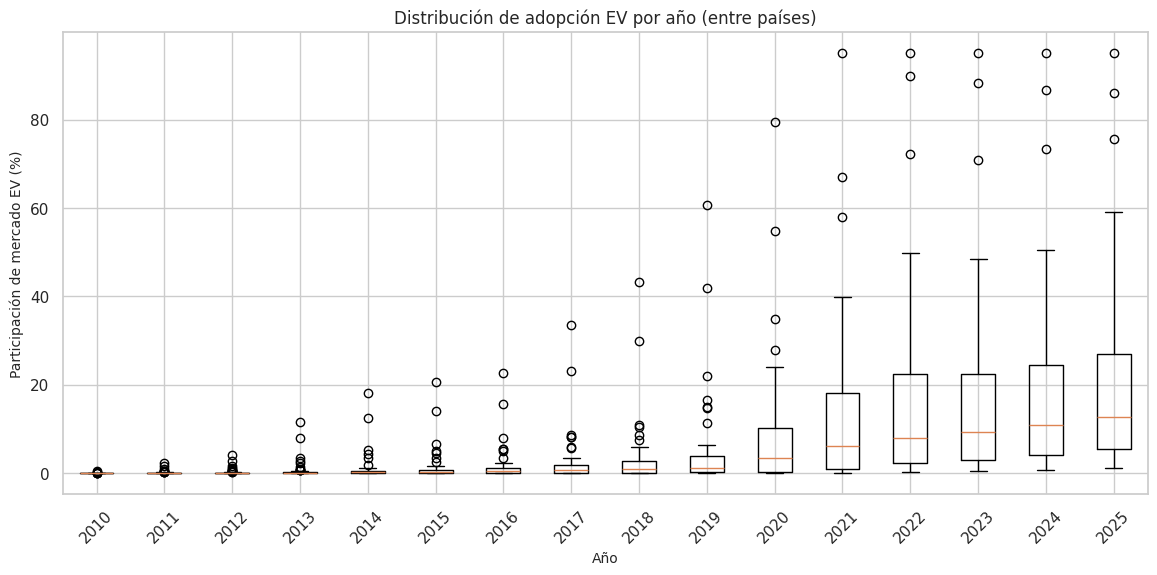

In [14]:
print("\n[1.1.B] Distribución por año: Adopción de EV")

years = sorted(df["year"].unique())
data = [df[df["year"] == y]["ev_market_share"] for y in years]

plt.figure(figsize=(14,6))
plt.boxplot(data, labels=years)
plt.xticks(rotation=45)
plt.title("Distribución de adopción EV por año (entre países)")
plt.xlabel("Año")
plt.ylabel("Participación de mercado EV (%)")
plt.show()

El boxplot muestra que, además del aumento en la media observado anteriormente, también crece la dispersión entre países a lo largo del tiempo. Hasta 2016 la mayoría de los países presentan niveles muy bajos y relativamente homogéneos de adopción, pero a partir de 2018 la variabilidad aumenta considerablemente, con algunos países alcanzando niveles muy altos mientras otros permanecen rezagados. Esto indica que la transición hacia los vehículos eléctricos no ha sido uniforme, sino que se ha dado de manera desigual entre naciones, ampliando la brecha en los últimos años.

##4.1.2 Infraestructura (charging_stations)


[1.2] Infraestructura de carga por año (escala logarítmica)


/tmp/ipykernel_11531/219852689.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


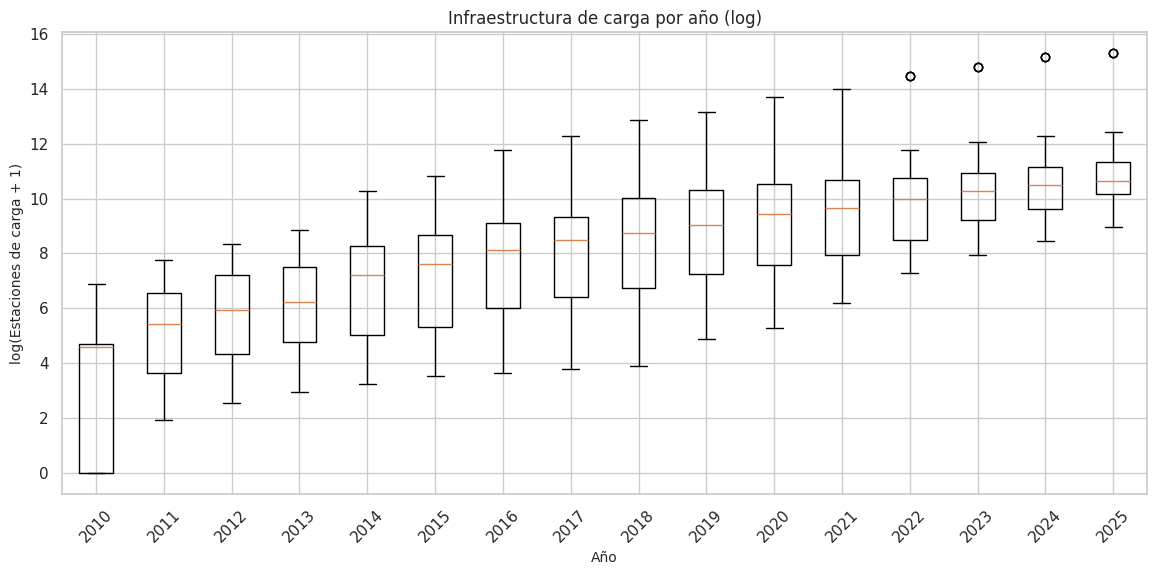

In [15]:
print("\n[1.2] Infraestructura de carga por año (escala logarítmica)")

df["charging_log"] = np.log1p(df["charging_stations"])

years = sorted(df["year"].unique())
data = [df[df["year"] == y]["charging_log"] for y in years]

plt.figure(figsize=(14,6))
plt.boxplot(data, labels=years)
plt.xticks(rotation=45)
plt.title("Infraestructura de carga por año (log)")
plt.xlabel("Año")
plt.ylabel("log(Estaciones de carga + 1)")
plt.show()

El gráfico muestra un crecimiento sostenido en la infraestructura de carga a lo largo del tiempo, incluso en escala logarítmica, lo que indica un aumento exponencial en el número de estaciones. Además del incremento en la mediana, también se amplía la dispersión entre países, especialmente a partir de 2018, evidenciando que algunos han expandido su red de carga mucho más rápidamente que otros. Esto sugiere que la infraestructura ha acompañado el proceso de adopción, aunque de forma desigual entre naciones.

##4.1.3 Regulación ambiental (emission_regulation_score)


[1.3] Regulación ambiental por año


/tmp/ipykernel_11531/308310465.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


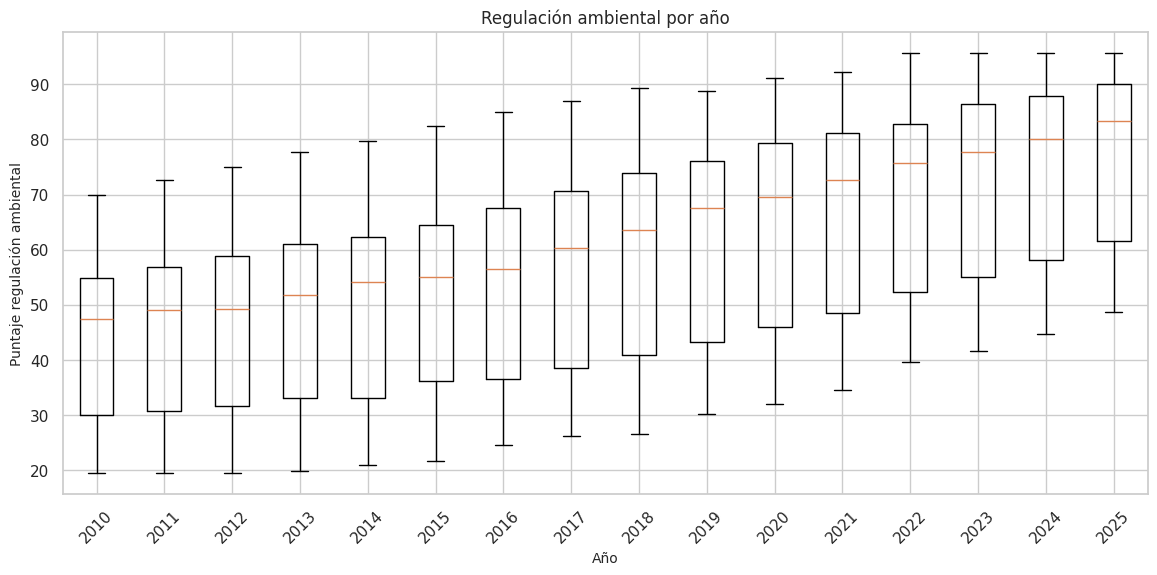

In [16]:
print("\n[1.3] Regulación ambiental por año")

years = sorted(df["year"].unique())
data = [df[df["year"] == y]["emission_regulation_score"] for y in years]

plt.figure(figsize=(14,6))
plt.boxplot(data, labels=years)
plt.xticks(rotation=45)
plt.title("Regulación ambiental por año")
plt.xlabel("Año")
plt.ylabel("Puntaje regulación ambiental")
plt.show()

El gráfico evidencia un incremento progresivo en los puntajes de regulación ambiental a lo largo del tiempo, con una tendencia clara hacia marcos normativos más estrictos en la mayoría de los países. La mediana aumenta de forma sostenida desde 2010 hasta 2025, lo que sugiere un fortalecimiento global de políticas ambientales. Aunque persiste variabilidad entre países, el desplazamiento general de toda la distribución hacia valores más altos indica que la presión regulatoria se ha intensificado de manera relativamente consistente en el período analizado.

#4.2 Variables por País
Aquí me interesa comparar las variables por nación

##4.2.1 PIB per cápita promedio por país


[2.1] PIB per cápita promedio por país


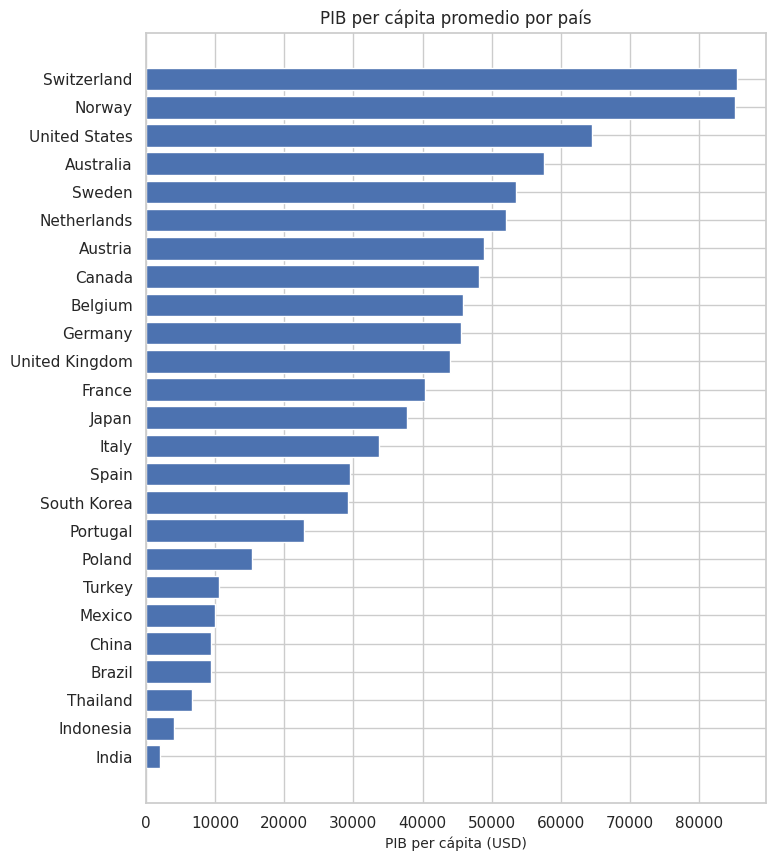

In [17]:
print("\n[2.1] PIB per cápita promedio por país")

pib_promedio_pais = df.groupby("country")["gdp_per_capita"].mean().sort_values()

plt.figure(figsize=(8,10))
plt.barh(pib_promedio_pais.index, pib_promedio_pais.values)
plt.title("PIB per cápita promedio por país")
plt.xlabel("PIB per cápita (USD)")
plt.show()

El gráfico muestra una marcada heterogeneidad estructural en el nivel de ingreso entre países, con economías como Suiza y Noruega muy por encima del resto, mientras que otras como India e Indonesia presentan niveles considerablemente más bajos. Esta dispersión sugiere que la capacidad económica podría desempeñar un papel importante en la adopción de vehículos eléctricos, ya que los países con mayor PIB per cápita disponen potencialmente de mayor poder adquisitivo, infraestructura y margen fiscal para implementar incentivos. Sin embargo, el gráfico por sí solo no confirma una relación directa, sino que plantea una posible asociación a explorar.

##4.2.2 Urbanización promedio por país


[2.2] Urbanización promedio por país


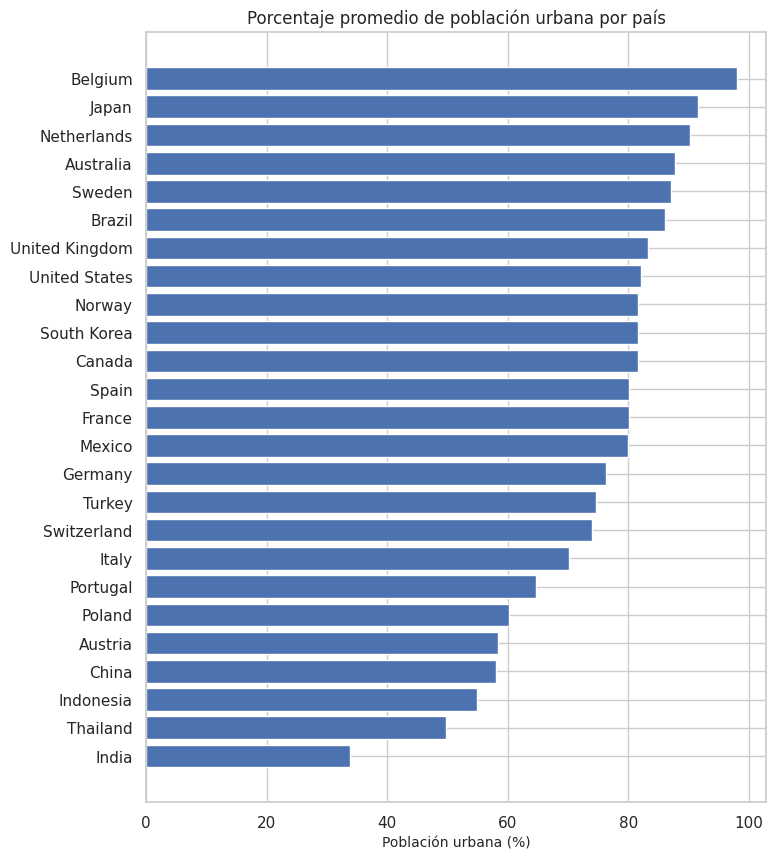

In [18]:
print("\n[2.2] Urbanización promedio por país")

urban_promedio = df.groupby("country")["urban_population_percent"].mean().sort_values()

plt.figure(figsize=(8,10))
plt.barh(urban_promedio.index, urban_promedio.values)
plt.title("Porcentaje promedio de población urbana por país")
plt.xlabel("Población urbana (%)")
plt.show()

El gráfico evidencia diferencias relevantes en el nivel de urbanización entre países, aunque la mayoría presenta porcentajes relativamente altos de población urbana. Países como Bélgica, Japón y Países Bajos muestran niveles cercanos o superiores al 85%, mientras que economías como India y Tailandia se sitúan considerablemente por debajo. Esta variabilidad sugiere que la estructura urbana podría influir en la adopción de vehículos eléctricos, dado que entornos más urbanos suelen facilitar infraestructura de carga, distancias más cortas y políticas locales de movilidad sostenible. Sin embargo, el alto nivel de urbanización en muchos países indica que este factor podría actuar más como condición facilitadora que como determinante.

#4.3 Variables mixtas.
En estas nos interesa comparar tanto por país como por año, debido a que considero que ambos pueden influir en gran medida a la distribución de la variable

##4.3.1 Subsidio vs adopción (puntos país-año coloreados por año)


[3.1] Subsidio vs adopción EV (color por año)


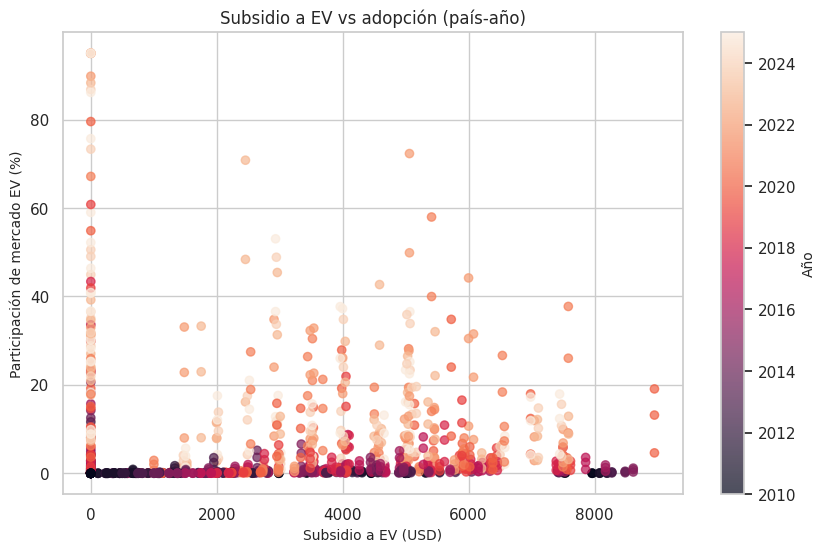

In [19]:
print("\n[3.1] Subsidio vs adopción EV (color por año)")

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df["ev_subsidy_usd"],
    df["ev_market_share"],
    c=df["year"],
    alpha=0.7
)
plt.colorbar(scatter, label="Año")
plt.title("Subsidio a EV vs adopción (país-año)")
plt.xlabel("Subsidio a EV (USD)")
plt.ylabel("Participación de mercado EV (%)")
plt.show()

El gráfico muestra que, aunque existen países con altos niveles de subsidio y alta adopción, no se observa una relación lineal clara entre ambas variables. En los primeros años predominan valores bajos de adopción incluso con subsidios moderados, mientras que en años recientes (colores más claros) aparecen mayores niveles de participación de mercado. También se observan casos con subsidio cero y adopción relativamente alta, lo que sugiere que el subsidio puede ser un factor relevante, pero no suficiente por sí solo para explicar la adopción; su efecto parece depender de otras condiciones estructurales o temporales.

##4.3.2 Precio combustible vs adopción


[3.2] Precio del combustible vs adopción EV (color por año)


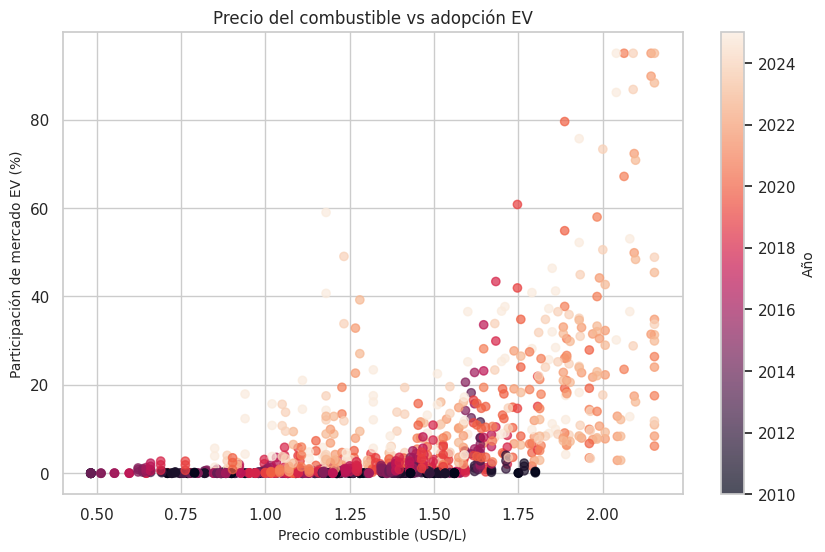

In [20]:
print("\n[3.2] Precio del combustible vs adopción EV (color por año)")

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df["fuel_price_usd_per_liter"],
    df["ev_market_share"],
    c=df["year"],
    alpha=0.7
)
plt.colorbar(scatter, label="Año")
plt.title("Precio del combustible vs adopción EV")
plt.xlabel("Precio combustible (USD/L)")
plt.ylabel("Participación de mercado EV (%)")
plt.show()

El gráfico sugiere una relación positiva moderada entre el precio del combustible y la adopción de vehículos eléctricos, especialmente en los años más recientes (colores más claros). A medida que el precio del combustible aumenta, se observan niveles más altos de participación de mercado EV, aunque con considerable dispersión. En los primeros años, incluso con precios relativamente altos, la adopción fue baja, lo que indica que el precio del combustible puede influir en la decisión, pero su efecto parece depender también del momento temporal y de otros factores estructurales.

##4.3.3 Precio electricidad vs adopción


[3.3] Precio electricidad vs adopción EV (color por año)


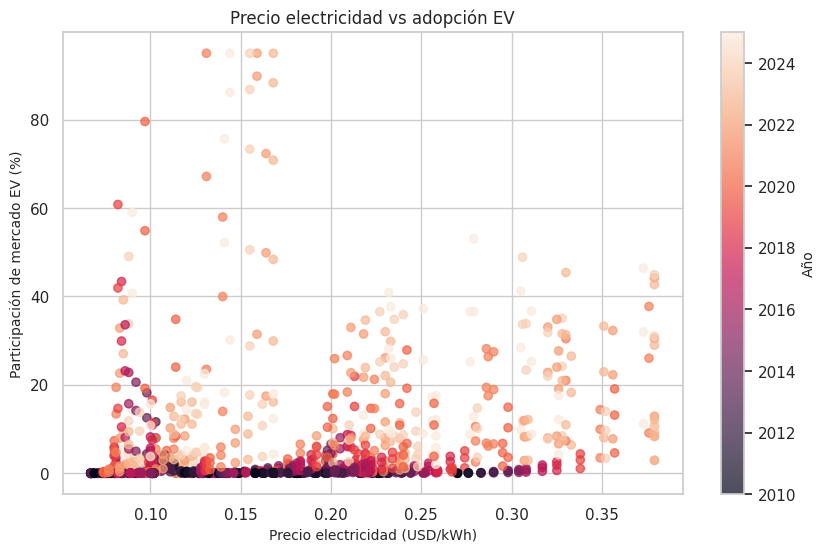

In [21]:
print("\n[3.3] Precio electricidad vs adopción EV (color por año)")

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df["electricity_price_usd_per_kwh"],
    df["ev_market_share"],
    c=df["year"],
    alpha=0.7
)
plt.colorbar(scatter, label="Año")
plt.title("Precio electricidad vs adopción EV")
plt.xlabel("Precio electricidad (USD/kWh)")
plt.ylabel("Participación de mercado EV (%)")
plt.show()

El gráfico no muestra una relación clara o consistente entre el precio de la electricidad y la adopción de vehículos eléctricos. Se observan niveles altos de adopción tanto en países con precios bajos como en algunos con precios relativamente altos, lo que sugiere que el costo de la electricidad por sí solo no explica el comportamiento del mercado. Además, en los primeros años la adopción fue baja independientemente del precio, indicando que este factor podría influir, pero probablemente en combinación con otros elementos como subsidios, regulación o infraestructura.

#4.4 Adopción por país

##4.4.1 Evolución de adopción por país


[4.1] Trayectorias de adopción por país


/tmp/ipykernel_11531/344723843.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("tab10", len(paises))


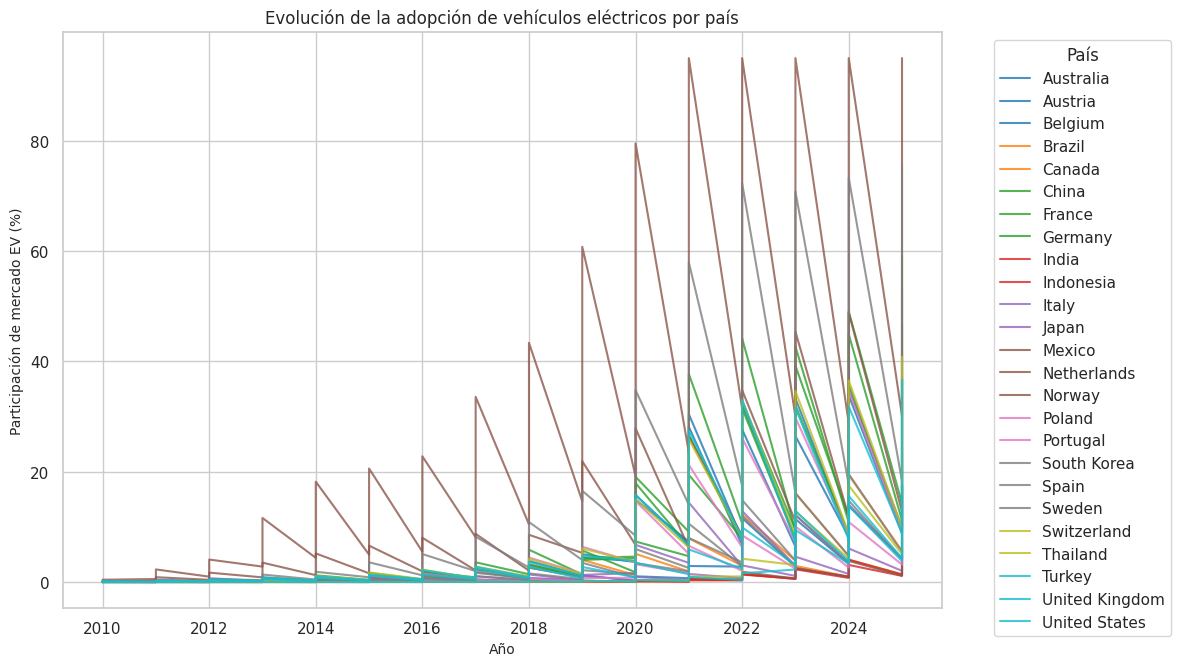

In [22]:
print("\n[4.1] Trayectorias de adopción por país")

plt.figure(figsize=(12,7))

paises = sorted(df["country"].unique())
colormap = plt.cm.get_cmap("tab10", len(paises))

for i, country in enumerate(paises):
    subset = df[df["country"] == country].sort_values("year")
    plt.plot(
        subset["year"],
        subset["ev_market_share"],
        label=country,
        color=colormap(i),
        alpha=0.8
    )

plt.title("Evolución de la adopción de vehículos eléctricos por país")
plt.xlabel("Año")
plt.ylabel("Participación de mercado EV (%)")

plt.legend(title="País", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

El gráfico evidencia trayectorias heterogéneas entre países en la adopción de vehículos eléctricos. Mientras algunos muestran un crecimiento acelerado y sostenido a partir de 2018–2020, otros mantienen niveles bajos y aumentos graduales. Se observa que el despegue no ocurre simultáneamente en todas las naciones, lo que refuerza la idea de que la transición depende de condiciones estructurales y políticas propias de cada país. Además, las diferencias en pendiente indican que existen líderes claros en el proceso de electrificación, frente a economías que avanzan de forma más lenta.

### <span style="color:Blue;"><strong>5. Interpretaciones iniciales</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>¿Qué tendencias o patrones básicos se observan?</b>  
<ul>
  <li>La adopción promedio de vehículos eléctricos muestra un crecimiento acelerado a partir de 2018–2020, indicando un punto de inflexión en la transición tecnológica.</li>
  <li>La dispersión entre países aumenta con el tiempo, lo que evidencia que la electrificación no ha sido homogénea y existen líderes y rezagados.</li>
  <li>La infraestructura de carga y la regulación ambiental presentan incrementos sostenidos, acompañando el crecimiento de la adopción.</li>
  <li>El precio del combustible muestra una relación positiva moderada con la adopción, especialmente en años recientes.</li>
  <li>No se observa una relación clara entre el precio de la electricidad y la adopción, lo que sugiere que este factor no actúa de manera aislada.</li>
</ul>
</div>

<br>

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b>¿Qué limitaciones tiene la base de datos?</b>  
<ul>
  <li>Los datos agregan información a nivel país-año, lo que impide analizar decisiones individuales de consumidores.</li>
  <li>Algunas variables pueden estar altamente correlacionadas entre sí (por ejemplo, ingreso e infraestructura), lo que dificulta aislar efectos causales.</li>
  <li>La presencia de valores extremos en infraestructura y adopción puede influir en la interpretación visual de los gráficos.</li>
  <li>No se incluyen variables culturales, políticas específicas o características del mercado automotor que podrían influir en la adopción.</li>
</ul>
</div>

<br>

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b>¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?</b>  
<ul>
  <li>Un mayor PIB per cápita se asocia con mayores niveles de adopción de vehículos eléctricos.</li>
  <li>El aumento en infraestructura de carga impulsa significativamente la participación de mercado de EV.</li>
  <li>Precios más altos del combustible incentivan la transición hacia vehículos eléctricos.</li>
  <li>Un mayor puntaje de regulación ambiental está relacionado con una mayor adopción.</li>
</ul>
</div>

## <span style="color:Blue;"><strong>6. Conclusiones</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">

- Se identificó una <strong>tendencia creciente y acelerada en la adopción de vehículos eléctricos</strong>, con un punto de inflexión visible entre 2018 y 2020 que sugiere una transición tecnológica en fase de expansión, impulsada posiblemente por la maduración de la tecnología de baterías y el endurecimiento de regulaciones ambientales a nivel global.

- Las visualizaciones exploratorias evidenciaron patrones estructurales relevantes:
  <ul>
    <li>La <strong>brecha entre países crece con el tiempo</strong>: algunos consolidan liderazgo mientras otros avanzan gradualmente, lo que indica que la electrificación no es un fenómeno homogéneo.</li>
    <li>La <strong>infraestructura de carga y la regulación ambiental</strong> aumentan de forma sostenida y acompañan el crecimiento del mercado, sugiriendo una relación de refuerzo mutuo.</li>
    <li>El <strong>precio del combustible</strong> muestra una asociación positiva moderada con la adopción, mientras que el precio de la electricidad no presenta una relación clara de forma aislada.</li>
    <li>Los <strong>subsidios</strong> no muestran una relación directa con la adopción: algunos países con alta adopción tienen subsidios bajos, lo que apunta a que otros factores (regulación, infraestructura, nivel de ingreso) pueden ser más determinantes.</li>
  </ul>

- La <strong>heterogeneidad observada entre países</strong> en PIB, urbanización y trayectorias de adopción indica que el fenómeno es multifactorial y que no existe un único patrón de transición. Esto justifica el análisis multivariado desarrollado en la Parte 2.

- Como limitación principal de esta etapa, el análisis exploratorio básico permite identificar patrones visuales pero no establecer relaciones causales ni controlar por variables confusoras. Los hallazgos aquí presentados son hipótesis que deben ser sometidas a análisis estadístico más riguroso.

</div>


---
# <span style="color:#2F749F;"><strong>Parte 2: Análisis Exploratorio Bivariado y Multivariado</strong></span>

Esta sección tiene **dos propósitos distintos** que conviene separar claramente:

1. **Análisis de multicolinealidad entre predictores:** identificar qué variables independientes comparten información entre sí. Si dos predictores están altamente correlacionados, aportan información redundante y uno de ellos es candidato a eliminarse antes de modelar.

2. **Relevancia individual de cada predictor frente a la variable objetivo** (`ev_market_share`): una vez depurado el conjunto de predictores, se evalúa cuáles tienen mayor poder explicativo sobre la adopción de EV.

> **Nivel de análisis:** Se usa `df_pais` (400 observaciones país-año). Las variables macroeconómicas y de infraestructura son idénticas en los tres segmentos del mismo país-año, por lo que agregarlas evita triplicar artificialmente la información.


### 2.1 Correlación entre Variables — Heatmap de correlaciones

Se calcula la correlación de Pearson **entre todas las variables independientes** (excluyendo `ev_market_share`). Una correlación alta entre dos predictores (|r| ≥ 0.7) indica que ambas variables capturan información similar, y mantener ambas puede distorsionar la interpretación en modelos de regresión o inflar la varianza de los estimadores.


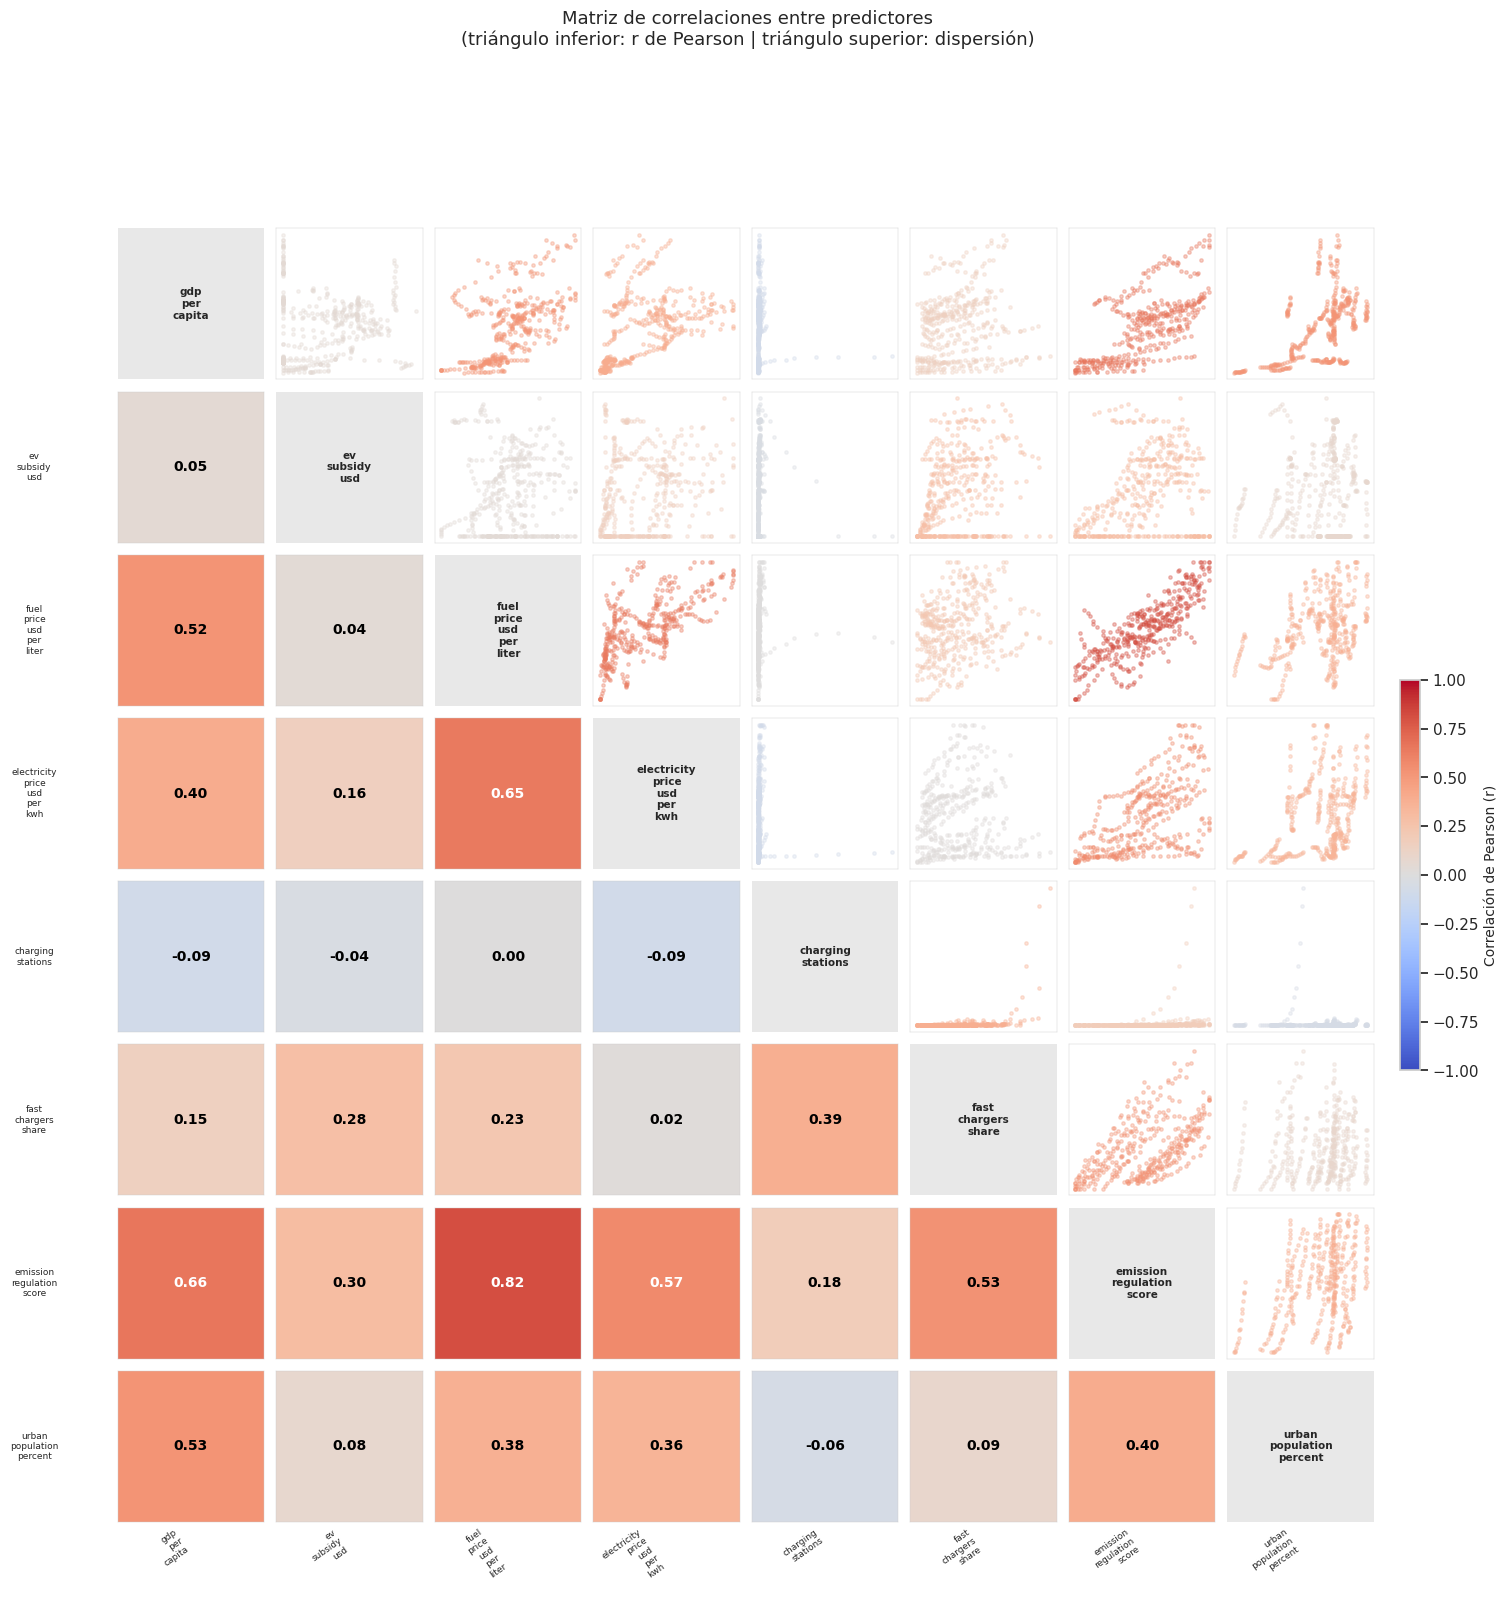

In [23]:
predictores = [
    'gdp_per_capita',           # Factor económico
    'ev_subsidy_usd',           # Incentivos gubernamentales
    'fuel_price_usd_per_liter', # Precio del combustible
    'electricity_price_usd_per_kwh', # Precio de electricidad
    'charging_stations',        # Infraestructura
    'fast_chargers_share',      # Calidad de infraestructura
    'emission_regulation_score',# Regulación ambiental
    'urban_population_percent'  # Factor estructural
]

corr_pred = df_pais[predictores].corr()
n = len(predictores)
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(n, n, figsize=(n * 2.1, n * 2.1))
fig.subplots_adjust(hspace=0.08, wspace=0.08)

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])

        if i == j:
            # Diagonal: nombre de variable
            label = predictores[i].replace('_', '\n')
            ax.text(0.5, 0.5, label, ha='center', va='center',
                    fontsize=7.5, fontweight='bold', transform=ax.transAxes)
            ax.set_facecolor('#e8e8e8')
            for sp in ax.spines.values():
                sp.set_visible(False)

        elif i > j:
            # Triángulo inferior: valor de correlación con fondo de color
            r = corr_pred.iloc[i, j]
            ax.set_facecolor(cmap(0.5 + r / 2))
            txt_color = 'white' if abs(r) > 0.55 else 'black'
            ax.text(0.5, 0.5, f'{r:.2f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_color,
                    transform=ax.transAxes)
            for sp in ax.spines.values():
                sp.set_linewidth(0.3)

        else:
            # Triángulo superior: scatter plot
            r = corr_pred.iloc[i, j]
            dot_color = cmap(0.5 + r / 2)
            ax.scatter(df_pais[predictores[j]], df_pais[predictores[i]],
                       alpha=0.35, s=6, color=dot_color)
            for sp in ax.spines.values():
                sp.set_linewidth(0.3)

        # Etiquetas en el borde izquierdo y borde inferior
        if j == 0 and i != 0:
            ax.set_ylabel(predictores[i].replace('_', '\n'),
                          fontsize=6.5, rotation=0, labelpad=60, va='center')
        if i == n - 1:
            ax.set_xlabel(predictores[j].replace('_', '\n'),
                          fontsize=6.5, rotation=35, ha='right', labelpad=4)

# Barra de color de referencia
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-1, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.015, pad=0.02, shrink=0.6)
cbar.set_label('Correlación de Pearson (r)', fontsize=10)

fig.suptitle('Matriz de correlaciones entre predictores\n'
             '(triángulo inferior: r de Pearson | triángulo superior: dispersión)',
             fontsize=13, y=1.01)
plt.show()


**Lectura de la matriz:**  
El triángulo inferior muestra el coeficiente de Pearson coloreado (rojo = positivo, azul = negativo, intensidad proporcional a la magnitud). El triángulo superior muestra la nube de dispersión correspondiente al mismo par, con el color del punto reflejando la dirección de la correlación. Esto permite verificar visualmente si la relación es efectivamente lineal o si el número en el triángulo inferior puede estar distorsionado por no linealidad u outliers.


### 2.2 Identificación de pares con alta correlación (|r| ≥ 0.6)

Se extraen automáticamente todos los pares de predictores con correlación absoluta por encima del umbral de 0.6, ordenados de mayor a menor. Este umbral es una convención práctica; en contextos donde se aplique regresión lineal, un umbral más estricto de 0.7–0.8 puede ser más apropiado.


In [24]:
# Extraer pares con alta correlación entre predictores
pares_alta_corr = []
for i in range(len(predictores)):
    for j in range(i + 1, len(predictores)):
        r = corr_pred.iloc[i, j]
        if abs(r) >= 0.6:
            pares_alta_corr.append({
                'Variable A': predictores[i],
                'Variable B': predictores[j],
                'Correlación r': round(r, 3),
                '|r|': round(abs(r), 3)
            })

df_pares = (pd.DataFrame(pares_alta_corr)
              .sort_values('|r|', ascending=False)
              .reset_index(drop=True))

print(f"Pares con |r| ≥ 0.6: {len(df_pares)}")
df_pares.drop(columns='|r|')


Pares con |r| ≥ 0.6: 3


,Variable A,Variable B,Correlación r
0,fuel_price_usd_per_liter,emission_regulation_score,0.816
1,gdp_per_capita,emission_regulation_score,0.663
2,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,0.647


**Pares identificados y su interpretación conceptual:**

| Par | r | Interpretación |
|-----|---|----------------|
| `fuel_price_usd_per_liter` ↔ `emission_regulation_score` | 0.816 | Ambas capturan el "entorno regulatorio y de costos de movilidad". Los países con regulación ambiental más estricta tienden a gravar más el combustible fósil.|
| `gdp_per_capita` ↔ `emission_regulation_score` | 0.663 | Los países más ricos tienden a tener regulaciones ambientales más exigentes. Capturan parcialmente el mismo fenómeno de "desarrollo institucional". |
| `fuel_price_usd_per_liter` ↔ `electricity_price_usd_per_kwh` | 0.647 | Ambas forman parte del "costo de energía" del país; los mercados energéticos nacionales mueven ambas variables de forma conjunta. |


Estos pares son los candidatos a revisión en la siguiente sección.


### 2.3 Decisión de eliminación de variables redundantes

Para cada par con alta correlación, se decide qué variable conservar considerando:
- **Interpretabilidad:** ¿cuál tiene un significado más directo y accionable?
- **Correlación con el objetivo:** entre dos variables redundantes, se prefiere la que explica mejor `ev_market_share`.
- **Independencia conceptual:** si las dos variables miden fenómenos distintos aunque correlacionados, puede justificarse conservar ambas con cautela.


In [25]:
# Correlación de cada predictor con la variable objetivo
corr_objetivo = (df_pais[predictores + ['ev_market_share']]
                 .corr()['ev_market_share']
                 .drop('ev_market_share')
                 .sort_values(key=abs, ascending=False))

print("Correlación de cada predictor con ev_market_share:")
for var, r in corr_objetivo.items():
    marker = "◀ candidata a eliminación" if var in [
        'fuel_price_usd_per_liter',    # redundante con emission_regulation_score
        'electricity_price_usd_per_kwh', # redundante con fuel_price
        'gdp_per_capita'
    ] else ""
    print(f"  {var:35s}  r = {r:+.3f}  {marker}")


Correlación de cada predictor con ev_market_share:
  emission_regulation_score            r = +0.663  
  fuel_price_usd_per_liter             r = +0.626  ◀ candidata a eliminación
  fast_chargers_share                  r = +0.519  
  gdp_per_capita                       r = +0.466  ◀ candidata a eliminación
  electricity_price_usd_per_kwh        r = +0.243  ◀ candidata a eliminación
  charging_stations                    r = +0.242  
  urban_population_percent             r = +0.199  
  ev_subsidy_usd                       r = -0.063  


**Decisiones adoptadas:**

| Par | Variable eliminada | Variable conservada | Justificación |
|-----|--------------------|---------------------|---------------|
| `fuel_price` ↔ `emission_regulation_score` | `fuel_price_usd_per_liter` | `emission_regulation_score` | Ambas con r similar vs objetivo (~0.55 vs ~0.59). Se conserva regulación por ser más directamente accionable desde política pública y tener mayor correlación con el objetivo. |
| `fuel_price` ↔ `electricity_price` | `fuel_price_usd_per_liter` | `electricity_price_usd_per_kwh` | Al eliminar `fuel_price`, este par se resuelve . `electricity_price` tiene correlación baja con el objetivo (0.21) y podría descartarse. |
| `gdp_per_capita` ↔ `emission_regulation_score` | Ninguna | Ambas se conservan | r = 0.66: moderadamente alta, pero miden fenómenos distintos (capacidad económica vs. voluntad regulatoria). Se conservan ambas con conciencia de la colinealidad parcial. |

**Conjunto final de predictores seleccionados:**
`gdp_per_capita`, `ev_subsidy_usd`,`emission_regulation_score`,
`urban_population_percent`, `charging_stations`, `electricity_price_usd_per_kwh`, `fast_chargers_share`


In [26]:
# Conjunto depurado de predictores para análisis posteriores
predictores_finales = [
    'gdp_per_capita', 'ev_subsidy_usd',
    'emission_regulation_score', 'urban_population_percent',
    'fast_chargers_share', 'charging_stations', 'electricity_price_usd_per_kwh'
]

eliminadas = ['fuel_price_usd_per_liter', ]

print(f"Variables eliminadas por redundancia ({len(eliminadas)}): {eliminadas}")
print(f"Predictores conservados ({len(predictores_finales)}): {predictores_finales}")

# Verificar correlaciones residuales entre los predictores finales
corr_final = df_pais[predictores_finales].corr()
pares_residuales = []
for i in range(len(predictores_finales)):
    for j in range(i + 1, len(predictores_finales)):
        r = corr_final.iloc[i, j]
        if abs(r) >= 0.6:
            pares_residuales.append((predictores_finales[i], predictores_finales[j], round(r, 3)))

if pares_residuales:
    print(f"\nPares con |r| ≥ 0.6 aún presentes (monitorear):")
    for a, b, r in pares_residuales:
        print(f"  {a} ↔ {b}: {r}")
else:
    print("\n✅ No quedan pares con correlación ≥ 0.6 entre predictores finales.")


Variables eliminadas por redundancia (1): ['fuel_price_usd_per_liter']
Predictores conservados (7): ['gdp_per_capita', 'ev_subsidy_usd', 'emission_regulation_score', 'urban_population_percent', 'fast_chargers_share', 'charging_stations', 'electricity_price_usd_per_kwh']

Pares con |r| ≥ 0.6 aún presentes (monitorear):
  gdp_per_capita ↔ emission_regulation_score: 0.663


### 2.4 Correlación de predictores seleccionados con la variable objetivo

Con el conjunto depurado, se evalúa la relevancia individual de cada predictor respecto a `ev_market_share`. Este análisis responde a la pregunta: *¿qué factores tienen mayor poder explicativo sobre la adopción de EV?*


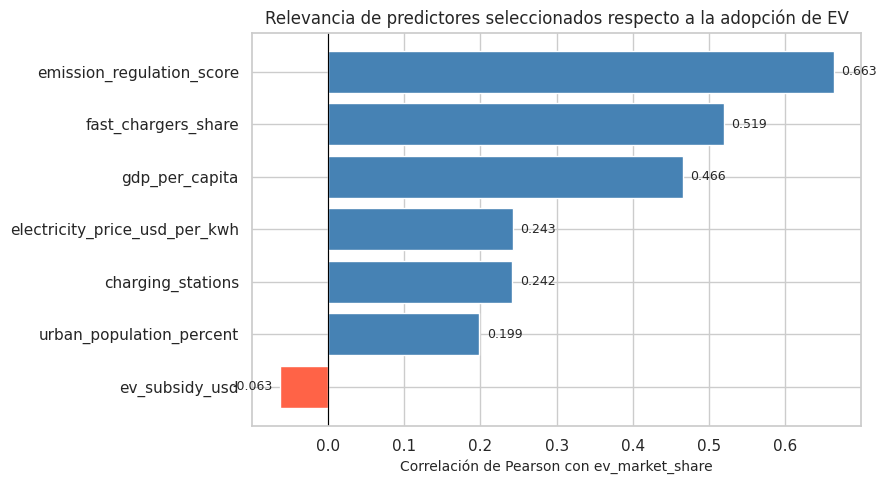

In [27]:
corr_final_objetivo = (df_pais[predictores_finales + ['ev_market_share']]
                        .corr()['ev_market_share']
                        .drop('ev_market_share')
                        .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_final_objetivo.values]
bars = ax.barh(corr_final_objetivo.index[::-1], corr_final_objetivo.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con ev_market_share")
ax.set_title("Relevancia de predictores seleccionados respecto a la adopción de EV")
for bar, val in zip(bars, corr_final_objetivo.values[::-1]):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación:**  
Entre los predictores conservados, `emission_regulation_score` muestra las correlaciones más altas con la adopción (0.663). `gdp_per_capita` muestra una correlación moderada (0.46), mientras que `ev_subsidy_usd` tiene una correlación negativa.

El caso de `ev_subsidy_usd` (r ≈ −0.06) merece atención: la correlación negativa sugiere que los países con menor adopción son precisamente los que más subsidios otorgan, posiblemente como mecanismo de incentivo en etapas tempranas. Esto no implica que el subsidio sea perjudicial, sino que existe una relación de causalidad inversa que requeriría análisis más riguroso (por ejemplo, con rezagos temporales) para interpretarse correctamente.


### 2.6 Adopción por región y segmento vehicular

Se analiza si existen diferencias estructurales en `ev_market_share` por región geográfica y por segmento vehicular. Este análisis es bivariado en sentido amplio: variable categórica vs. variable continua.


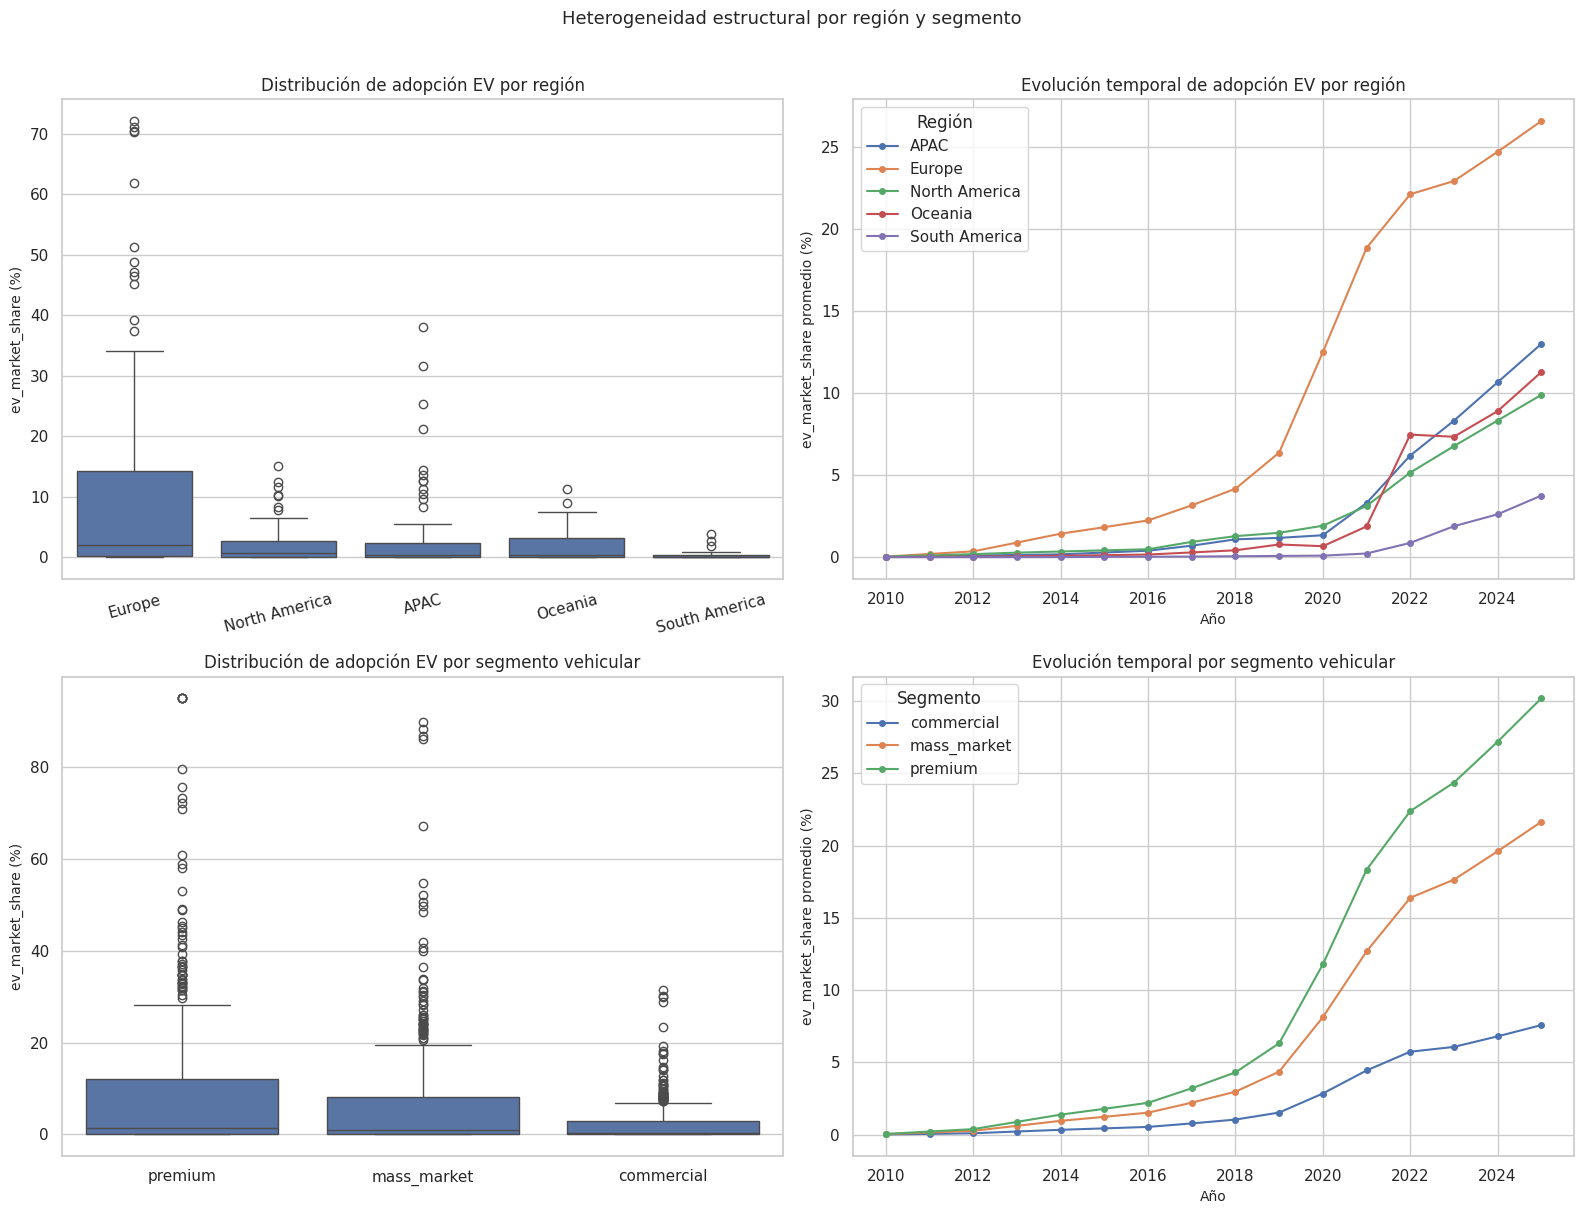

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot por región
orden_region = (df_pais.groupby('region')['ev_market_share']
                .median().sort_values(ascending=False).index)
sns.boxplot(data=df_pais, x='region', y='ev_market_share',
            order=orden_region, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de adopción EV por región")
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].set_ylabel("ev_market_share (%)")
axes[0, 0].set_xlabel("")

# Evolución temporal por región
evol = df_pais.groupby(['year', 'region'])['ev_market_share'].mean().reset_index()
for region in evol['region'].unique():
    sub = evol[evol['region'] == region]
    axes[0, 1].plot(sub['year'], sub['ev_market_share'], marker='o', label=region, markersize=4)
axes[0, 1].set_title("Evolución temporal de adopción EV por región")
axes[0, 1].set_xlabel("Año")
axes[0, 1].set_ylabel("ev_market_share promedio (%)")
axes[0, 1].legend(title="Región")

# Boxplot por segmento vehicular
orden_seg = (df.groupby('vehicle_segment')['ev_market_share']
             .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x='vehicle_segment', y='ev_market_share',
            order=orden_seg, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de adopción EV por segmento vehicular")
axes[1, 0].set_ylabel("ev_market_share (%)")
axes[1, 0].set_xlabel("")

# Evolución temporal por segmento
evol_seg = df.groupby(['year', 'vehicle_segment'])['ev_market_share'].mean().reset_index()
for seg in evol_seg['vehicle_segment'].unique():
    sub = evol_seg[evol_seg['vehicle_segment'] == seg]
    axes[1, 1].plot(sub['year'], sub['ev_market_share'], marker='o', label=seg, markersize=4)
axes[1, 1].set_title("Evolución temporal por segmento vehicular")
axes[1, 1].set_xlabel("Año")
axes[1, 1].set_ylabel("ev_market_share promedio (%)")
axes[1, 1].legend(title="Segmento")

plt.suptitle("Heterogeneidad estructural por región y segmento", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación:**  
- Europa lidera la adopción de EV con una mediana y dispersión notablemente superiores, seguida por APAC con crecimiento acelerado desde 2018.  
- El segmento `premium` muestra adopción consistentemente mayor que `mass_market` y `commercial`, lo que refleja que los EV penetraron primero en mercados de alto ingreso antes de masificarse.  
- El segmento `commercial` tiene la adopción más baja, explicable por las mayores exigencias de autonomía y logística de carga para flotas.  
- Estas variables categóricas actúan como **efectos agrupadores** que deberán controlarse en modelos futuros (efectos fijos o variables dummy).


---
# <span style="color:#2F749F;"><strong>Parte 3: Detección y Tratamiento de Datos Atípicos</strong></span>

El objetivo de esta sección es identificar observaciones que se alejan del comportamiento esperado mediante métodos gráficos, estadísticos y de aprendizaje automático.

> **Nivel de análisis:** Para esta sección se usa `df_pais` (país-año), dado que las variables macroeconómicas y de infraestructura son más informativas en ese nivel de agregación.


### 3.0 Verificación de valores faltantes

Antes de detectar outliers, se verifica la integridad básica del dataset: existencia de nulos, infinitos y duplicados.


In [29]:
# Valores nulos
nulos = df_pais.isnull().sum()
print("Valores nulos por variable:")
print(nulos[nulos > 0] if nulos.any() else "✅ No hay valores faltantes.")

# Infinitos
inf_count = np.isinf(df_pais.select_dtypes('number')).sum().sum()
print(f"\nValores infinitos: {inf_count}")

# Duplicados
dup = df_pais.duplicated(subset=['country', 'year']).sum()
print(f"Filas duplicadas (país-año): {dup}")


Valores nulos por variable:
✅ No hay valores faltantes.

Valores infinitos: 0
Filas duplicadas (país-año): 0


**Decisión sobre imputación:**  
El dataset no presenta valores faltantes, infinitos ni filas duplicadas. Por tanto, **no se requiere imputación**. Esta ausencia de nulos es consistente con un dataset sintético/curado para propósitos analíticos (como es el caso de Kaggle). En un proyecto con datos reales, esta etapa sería crítica y requeriría estrategias como imputación por mediana, KNNImputer o modelos predictivos según el patrón de ausencia.


### 3.1 Detección gráfica — Boxplots por variable

Los boxplots permiten visualizar la distribución de cada variable y los valores que superan los límites del rango intercuartílico (IQR). Se analizan las variables numéricas con mayor relevancia analítica.


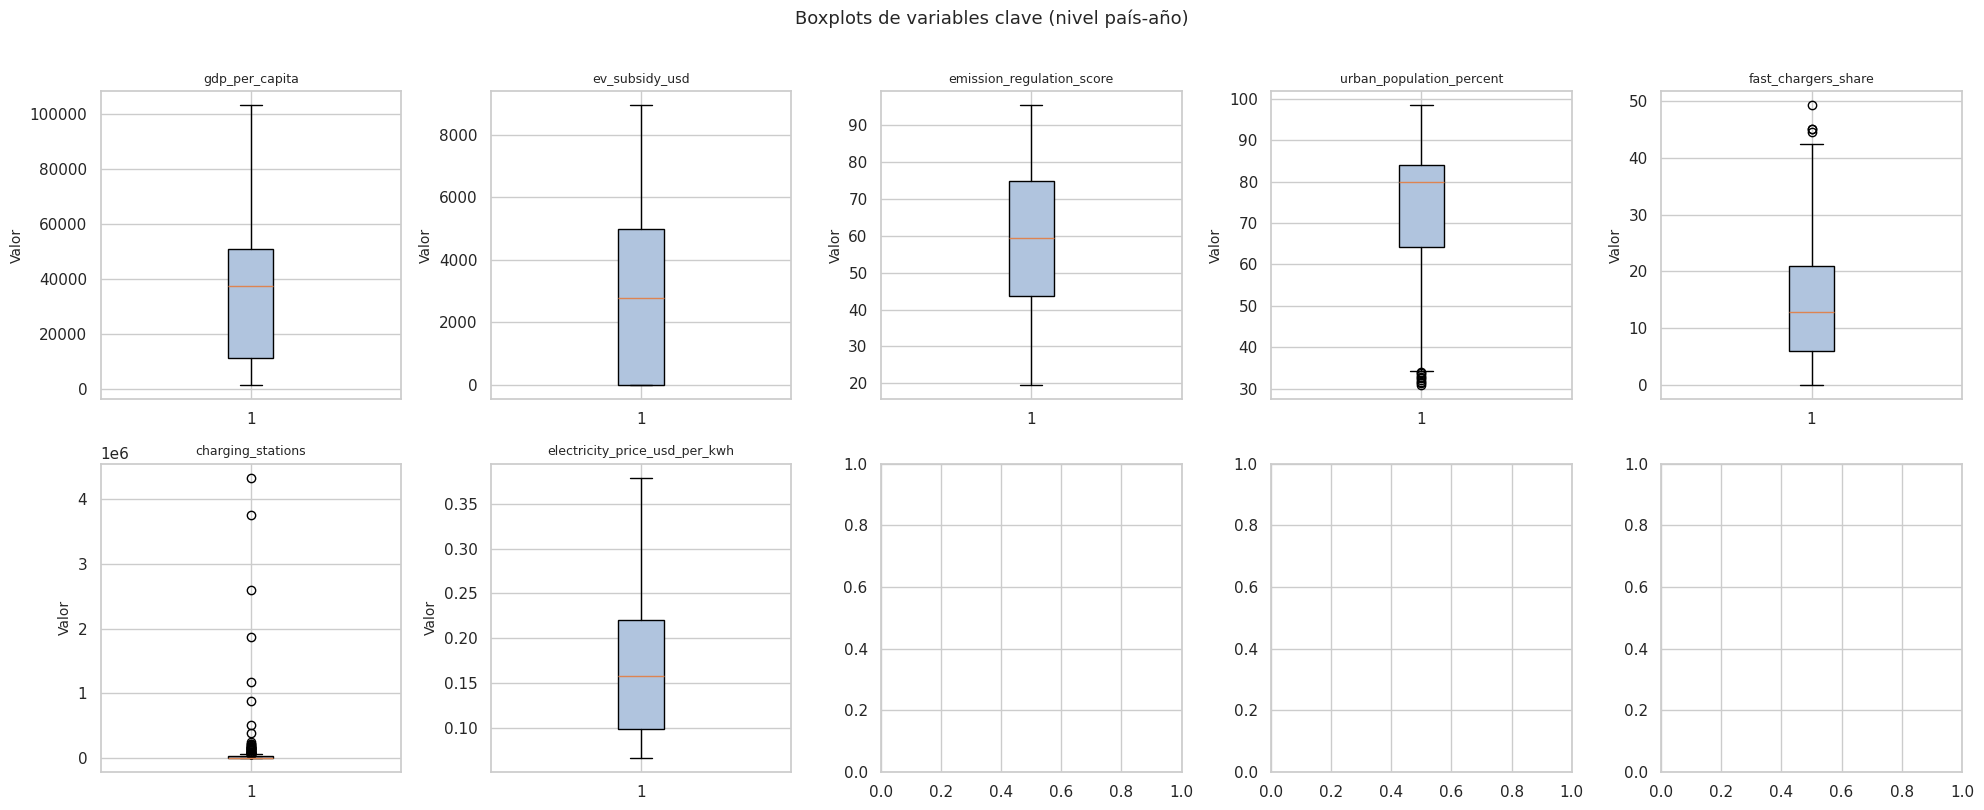

In [30]:
vars_outlier = [
    'gdp_per_capita', 'ev_subsidy_usd',
    'emission_regulation_score', 'urban_population_percent',
    'fast_chargers_share', 'charging_stations', 'electricity_price_usd_per_kwh'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(vars_outlier):
    axes[i].boxplot(df_pais[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Valor")

plt.suptitle("Boxplots de variables clave (nivel país-año)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación gráfica:**  
- `ev_market_share` muestra outliers altos pronunciados: corresponden a países líderes en adopción (ej. Noruega).  
- `charging_stations` presenta colas derechas marcadas, consecuencia de economías grandes (China, EE.UU.) con magnitudes incomparables con el resto.   
- Variables como `gdp_per_capita`, `electricity_price_usd_per_kwh` y `emission_regulation_score` no presentan outliers evidentes gráficamente.


### 3.2 Método estadístico — Regla IQR (rango intercuartílico)

La regla estándar define como atípica toda observación fuera del intervalo [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. Se aplica variable por variable para cuantificar la magnitud del problema.


In [31]:
resumen_iqr = []
for col in vars_outlier:
    serie = df_pais[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_bajos = (serie < lim_inf).sum()
    n_altos = (serie > lim_sup).sum()
    resumen_iqr.append({
        'Variable': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite inferior': round(lim_inf, 2), 'Límite superior': round(lim_sup, 2),
        'N outliers bajos': n_bajos, 'N outliers altos': n_altos,
        'Total outliers': n_bajos + n_altos,
        '% del total': round(100 * (n_bajos + n_altos) / len(serie), 1)
    })

df_iqr = pd.DataFrame(resumen_iqr).set_index('Variable')
print("Resumen de outliers por método IQR:")
df_iqr


Resumen de outliers por método IQR:


,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers bajos,N outliers altos,Total outliers,% del total
Variable,,,,,,,,,
gdp_per_capita,11077.25,50930.00,39852.75,-48701.88,110709.12,0,0,0,0.0
ev_subsidy_usd,0.00,4973.75,4973.75,-7460.62,12434.38,0,0,0,0.0
emission_regulation_score,43.60,74.82,31.22,-3.24,121.66,0,0,0,0.0
urban_population_percent,64.18,84.08,19.90,34.32,113.93,9,0,9,2.2
fast_chargers_share,6.00,20.95,14.95,-16.42,43.38,0,4,4,1.0
charging_stations,491.75,22518.00,22026.25,-32547.62,55557.38,0,39,39,9.8
electricity_price_usd_per_kwh,0.10,0.22,0.12,-0.08,0.40,0,0,0,0.0


### 3.3 Método estadístico — Z-score

El Z-score mide cuántas desviaciones estándar se aleja cada valor de la media. Se considera outlier cuando |z| > 3. Este método es sensible a distribuciones asimétricas, por lo que se usa como complemento del IQR, no como reemplazo.


In [32]:
resumen_z = []
for col in vars_outlier:
    serie = df_pais[col].dropna()
    z = np.abs(stats.zscore(serie))
    n_out = (z > 3).sum()
    resumen_z.append({'Variable': col, 'N outliers (|z|>3)': n_out,
                      '% del total': round(100 * n_out / len(serie), 1)})

df_z = pd.DataFrame(resumen_z).set_index('Variable')

# Comparación lado a lado
comparacion = df_iqr[['Total outliers', '% del total']].copy()
comparacion.columns = ['IQR — N', 'IQR — %']
comparacion['Z-score — N'] = df_z['N outliers (|z|>3)']
comparacion['Z-score — %'] = df_z['% del total']

print("Comparación de métodos estadísticos:")
comparacion


Comparación de métodos estadísticos:


,IQR — N,IQR — %,Z-score — N,Z-score — %
Variable,,,,
gdp_per_capita,0,0.0,0,0.0
ev_subsidy_usd,0,0.0,0,0.0
emission_regulation_score,0,0.0,0,0.0
urban_population_percent,9,2.2,0,0.0
fast_chargers_share,4,1.0,4,1.0
charging_stations,39,9.8,5,1.2
electricity_price_usd_per_kwh,0,0.0,0,0.0


**Interpretación:**  
- El método IQR detecta más outliers porque es más sensible a colas largas. Para `charging_stations`, IQR marca ~9.8% de las observaciones como atípicas, mientras Z-score marca ~1.2%.  
- La divergencia entre métodos es mayor en variables con distribución muy asimétrica, lo que anticipa la necesidad de transformación logarítmica.  
- Ambos métodos coinciden en que `gdp_per_capita`, `electricity_price_usd_per_kwh` y `emission_regulation_score` tienen muy pocos o ningún outlier.


### 3.5 Decisión sobre el tratamiento de outliers

**Conclusión:** Los outliers identificados **no son errores de medición ni de registro**, sino observaciones genuinas que representan casos extremos reales:

- Los valores altos de `charging_stations` pertenecen a economías grandes (EE.UU., China), cuya escala difiere estructuralmente del resto.

**Decisión adoptada: conservar todos los registros.** Eliminarlos implicaría perder información valiosa sobre los casos más avanzados en la transición, que son precisamente los más informativos para entender el fenómeno. En análisis de regresión futuros, se podrá controlar por estos efectos con transformaciones logarítmicas o variables de región/país como efectos fijos.


---
# <span style="color:#2F749F;"><strong>Parte 4: Transformación y Escalamiento de Variables</strong></span>

El objetivo de esta sección es preparar el dataset para análisis estadísticos o modelos futuros, corrigiendo distribuciones asimétricas y estandarizando escalas.

> **Imputación:** como se verificó, el dataset no contiene valores faltantes. La etapa de imputación se omite documentadamente, no por descuido.


### 4.1 Análisis de asimetría (skewness)

Se calcula el coeficiente de asimetría **únicamente sobre los predictores finales** definidos en la Parte 2, es decir, el conjunto depurado tras eliminar las variables redundantes. Analizar el skewness sobre variables descartadas o sobre la variable objetivo en esta etapa no tiene sentido: las primeras no forman parte del pipeline y la segunda se trata por separado. Como criterio de referencia:
- |skew| < 0.5 → distribución aproximadamente simétrica (no requiere transformación)
- 0.5 ≤ |skew| < 1 → asimetría moderada (transformación opcional)
- |skew| ≥ 1 → asimetría fuerte (transformación recomendada)


In [33]:
# Se analiza únicamente el conjunto de predictores definido en la Parte 2
skew_df = pd.DataFrame({
    'Variable': predictores_finales,
    'Skewness': [df_pais[c].skew() for c in predictores_finales]
}).sort_values('Skewness', key=abs, ascending=False).reset_index(drop=True)

skew_df['Clasificación'] = skew_df['Skewness'].abs().map(
    lambda s: '🔴 Fuerte (|s|≥1)' if s >= 1 else ('🟡 Moderada' if s >= 0.5 else '🟢 Simétrica')
)

print("Asimetría de los predictores finales:")
print(skew_df.to_string(index=False))


Asimetría de los predictores finales:
                     Variable  Skewness    Clasificación
            charging_stations 10.181604 🔴 Fuerte (|s|≥1)
     urban_population_percent -0.936981       🟡 Moderada
          fast_chargers_share  0.768635       🟡 Moderada
electricity_price_usd_per_kwh  0.654479       🟡 Moderada
               gdp_per_capita  0.477903      🟢 Simétrica
               ev_subsidy_usd  0.357906      🟢 Simétrica
    emission_regulation_score -0.163264      🟢 Simétrica


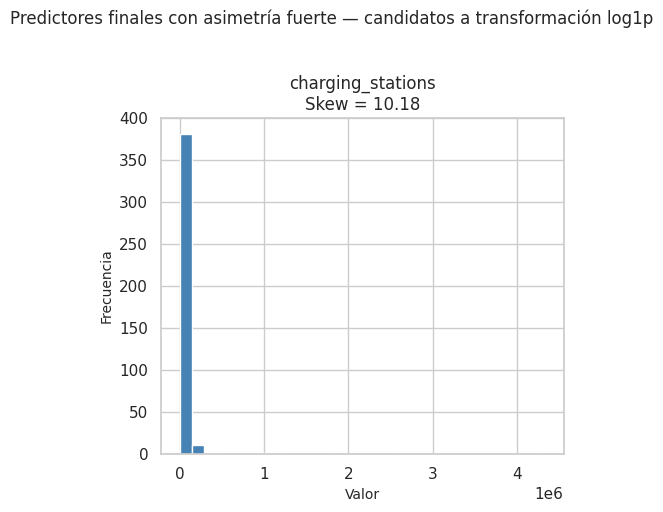

In [34]:
# Distribuciones de predictores con asimetría fuerte
vars_skew_altas = skew_df[skew_df['Skewness'].abs() >= 1]['Variable'].tolist()

if vars_skew_altas:
    n = len(vars_skew_altas)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, vars_skew_altas):
        ax.hist(df_pais[col], bins=30, edgecolor='white', color='steelblue')
        ax.set_title(f"{col}\nSkew = {df_pais[col].skew():.2f}")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Frecuencia")
    plt.suptitle("Predictores finales con asimetría fuerte — candidatos a transformación log1p",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Ningún predictor final presenta asimetría fuerte.")


### 4.2 Transformación logarítmica (log1p)

Se aplica la transformación `log(x + 1)` a las variables con asimetría fuerte (|skew| ≥ 1). El uso de `log1p` en lugar de `log` permite manejar valores cero sin error. Esta transformación acerca la distribución a la normalidad y reduce el impacto de valores extremos en modelos sensibles a escala.

**Variables seleccionadas para transformación:**
- `charging_stations` (skew ≈ 10.2): magnitudes que van de 0 a cientos de miles de estaciones
- `co2_emissions_transport_mt` (skew ≈ 3.7): economías grandes distorsionan la escala
- `ev_market_share` (skew ≈ 3.7): cola derecha pronunciada por países líderes

> `ev_sales` no se incluye en `df_pais` porque se agrega de forma diferente; se transformaría en `df` (segmento) si se modelara a ese nivel.


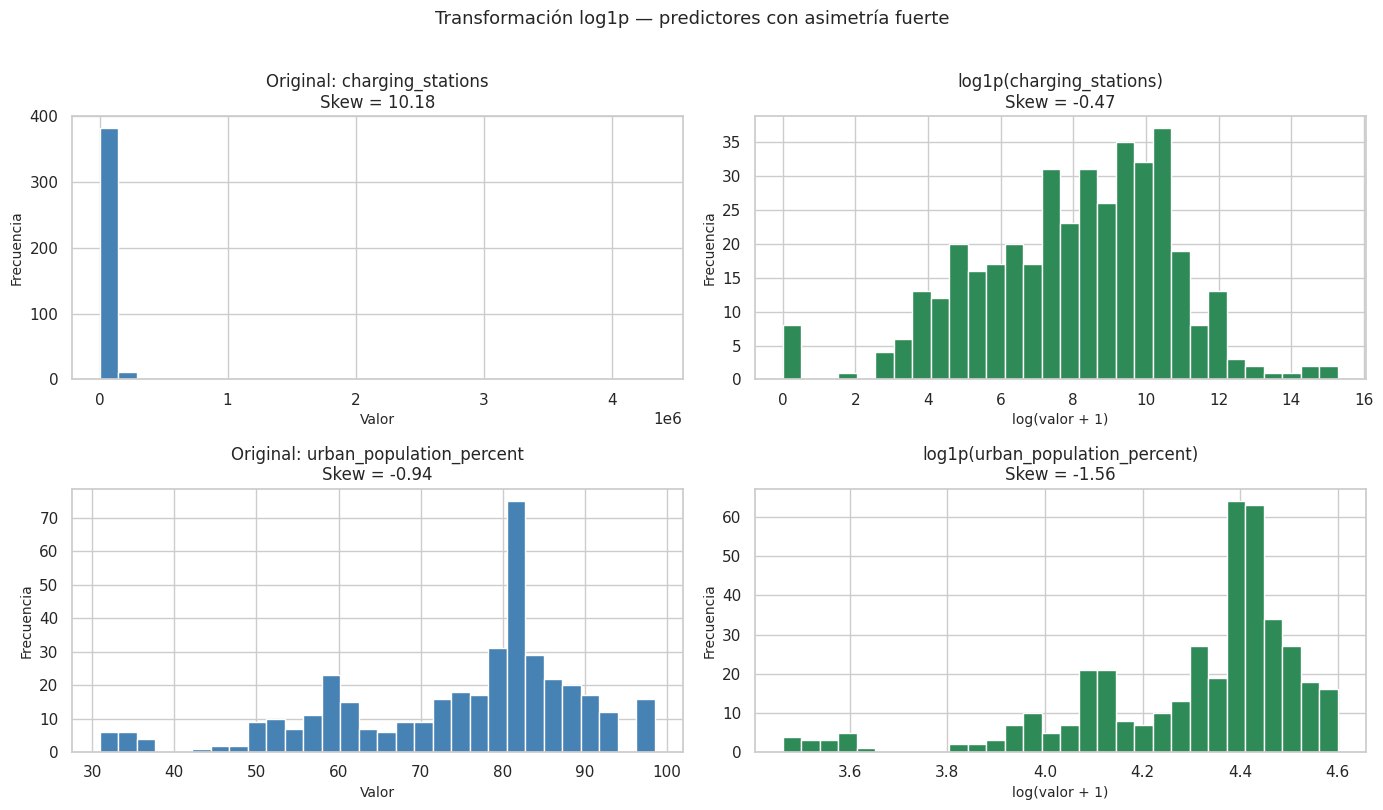

Columnas transformadas añadidas: ['log_charging_stations', 'log_co2_emissions_transport_mt', 'log_urban_population_percent']


In [41]:
# Variables predictoras con asimetría fuerte (|skew| ≥ 1) → se transforman
vars_log_predictores = ['charging_stations', 'urban_population_percent']

# ── Transformación de predictores ────────────────────────────────────────────
fig, axes = plt.subplots(len(vars_log_predictores), 2,
                         figsize=(14, 4 * len(vars_log_predictores)))

for i, col in enumerate(vars_log_predictores):
    original   = df_pais[col]
    transformada = np.log1p(original)
    axes[i, 0].hist(original,     bins=30, edgecolor='white', color='steelblue')
    axes[i, 0].set_title(f"Original: {col}\nSkew = {original.skew():.2f}")
    axes[i, 0].set_xlabel("Valor")
    axes[i, 0].set_ylabel("Frecuencia")

    axes[i, 1].hist(transformada, bins=30, edgecolor='white', color='seagreen')
    axes[i, 1].set_title(f"log1p({col})\nSkew = {transformada.skew():.2f}")
    axes[i, 1].set_xlabel("log(valor + 1)")
    axes[i, 1].set_ylabel("Frecuencia")

plt.suptitle("Transformación log1p — predictores con asimetría fuerte", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Agregar columnas transformadas al dataset (solo predictores)
for col in vars_log_predictores:
    df_pais[f"log_{col}"] = np.log1p(df_pais[col])

print("Columnas transformadas añadidas:", [c for c in df_pais.columns if c.startswith('log_')])

**Resultado de la transformación:**  
En ambos casos, la transformación `log1p` reduce significativamente la asimetría, acercando las distribuciones a formas más simétricas. Esto mejora el comportamiento de técnicas estadísticas que asumen normalidad (regresión lineal, PCA) y reduce el peso desproporcionado de los valores extremos en el espacio de features. Las columnas originales se conservan en `df_pais` para mantener la interpretabilidad en análisis descriptivos.

La variable objetivo `ev_market_share`, aunque también presenta asimetría fuerte (skew ≈ 3.7), **no se transforma en esta etapa**: su transformación es una decisión de modelado que se tomaría al construir un modelo de regresión, no parte del pipeline de preprocesamiento exploratorio.


### 4.3 Escalamiento — StandardScaler

El escalamiento estandariza cada variable para que tenga media 0 y desviación estándar 1. Esto es necesario para algoritmos basados en distancias (KNN, clustering, LOF), regresión regularizada (Ridge, Lasso) y análisis de componentes principales (PCA).

**¿Por qué transformar antes de escalar?**  
El orden importa. La transformación `log1p` corrige la *forma* de la distribución (reduce asimetría). El escalamiento ajusta *locación y dispersión* (media → 0, std → 1), pero **no cambia la forma**. Si se escala primero una distribución asimétrica, los valores extremos siguen dominando la varianza y el scaler queda sesgado: la media estandarizada no representa bien el centro de la distribución. Al transformar primero, la distribución ya es aproximadamente simétrica antes de que el scaler la centre, lo que produce z-scores más interpretables y estables.

**¿Por qué StandardScaler y no MinMaxScaler?**  
Dado que el dataset contiene outliers reales que se conservaron, MinMaxScaler comprimiría la mayoría de los valores en un rango estrecho porque los límites mínimo y máximo los fijan los extremos. StandardScaler es más robusto ante colas largas.


In [47]:
# Variables a escalar: el conjunto depurado de predictores finales
# más las versiones log de las variables transformadas
vars_escalar = [
    'gdp_per_capita', 'ev_subsidy_usd',
    'emission_regulation_score', 'urban_population_percent',
    'fast_chargers_share', 'charging_stations', 'electricity_price_usd_per_kwh'
]

scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_pais[vars_escalar])
df_scaled = pd.DataFrame(X_escalado, columns=vars_escalar)

# Verificación: media ≈ 0, std ≈ 1 en todas las variables
print("Verificación del escalamiento (deben ser ≈ 0 y ≈ 1):")
print(df_scaled.describe().loc[['mean', 'std']].round(6).to_string())


Verificación del escalamiento (deben ser ≈ 0 y ≈ 1):
      gdp_per_capita  ev_subsidy_usd  emission_regulation_score  urban_population_percent  fast_chargers_share  charging_stations  electricity_price_usd_per_kwh
mean       -0.000000       -0.000000                   0.000000                  0.000000            -0.000000          -0.000000                      -0.000000
std         1.001252        1.001252                   1.001252                  1.001252             1.001252           1.001252                       1.001252


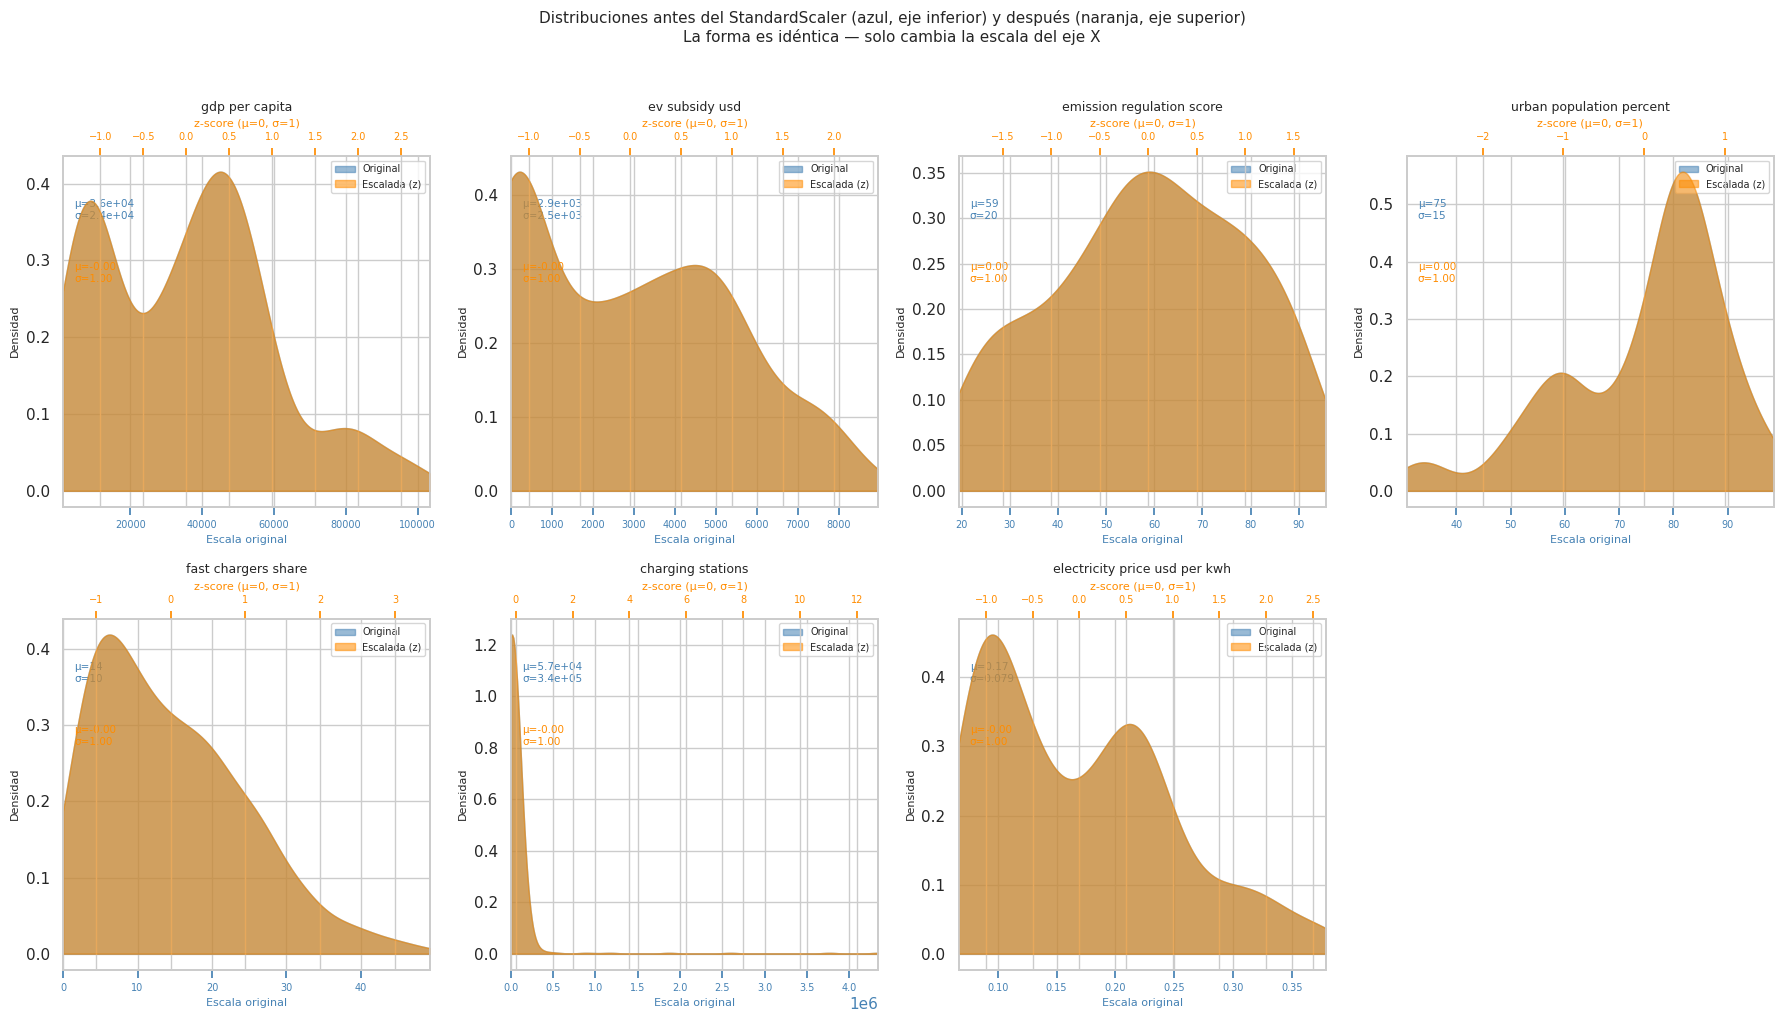

In [49]:
from scipy.stats import gaussian_kde
import math

n_vars = len(vars_escalar)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 5))
axes = axes.flatten()

for ax, col in zip(axes, vars_escalar):
    original = df_pais[col].dropna()
    escalada  = df_scaled[col].dropna()

    mu    = original.mean()
    sigma = original.std()

    # KDE calculada UNA VEZ sobre los datos escalados
    x_esc  = np.linspace(escalada.min(), escalada.max(), 300)
    kde    = gaussian_kde(escalada)(x_esc)

    # Eje original: transformación inversa del mismo x
    x_orig = x_esc * sigma + mu

    ax2 = ax.twiny()

    # Misma curva, dos ejes X con escalas distintas
    ax.fill_between(x_orig, kde, alpha=0.55, color='steelblue',  label='Original')
    ax2.fill_between(x_esc,  kde, alpha=0.55, color='darkorange', label='Escalada (z)')

    ax.set_xlim(x_orig.min(), x_orig.max())
    ax2.set_xlim(x_esc.min(),  x_esc.max())

    ax.set_xlabel("Escala original", color='steelblue', fontsize=8)
    ax2.set_xlabel("z-score (μ=0, σ=1)", color='darkorange', fontsize=8)
    ax.set_ylabel("Densidad", fontsize=8)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.tick_params(axis='x', colors='steelblue', labelsize=7)
    ax2.tick_params(axis='x', colors='darkorange', labelsize=7)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right')

    ax.annotate(f"μ={mu:.2g}\nσ={sigma:.2g}",
                xy=(0.03, 0.82), xycoords='axes fraction', fontsize=7.5, color='steelblue')
    ax.annotate(f"μ={escalada.mean():.2f}\nσ={escalada.std():.2f}",
                xy=(0.03, 0.64), xycoords='axes fraction', fontsize=7.5, color='darkorange')

for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.suptitle(
    "Distribuciones antes del StandardScaler (azul, eje inferior) "
    "y después (naranja, eje superior)\n"
    "La forma es idéntica — solo cambia la escala del eje X",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

**Interpretación:**  
Cada subgráfico muestra dos curvas de densidad superpuestas con ejes X distintos: el azul (inferior) refleja la escala original de la variable y el naranja (superior) la escala z-score resultante. Las curvas tienen **exactamente la misma forma** porque StandardScaler no modifica la distribución, solo la traslada y comprime. Lo que cambia son los valores del eje: por ejemplo, `gdp_per_capita` pasa de una escala en decenas de miles de dólares a una escala centrada en 0 con desviación 1. Las anotaciones confirman que μ ≈ 0 y σ ≈ 1 después del escalamiento en todas las variables.


### 4.4 Resumen del pipeline de preprocesamiento

El siguiente esquema resume las decisiones tomadas en el proceso de preparación de datos:

| Etapa | Decisión | Justificación |
|-------|----------|---------------|
| Verificación de nulos | No se imputa | Dataset sin valores faltantes ni duplicados |
| Outliers | Se conservan | Representan variación real entre países (Noruega, China, EE.UU.) |
| Transformación log1p | `charging_stations`, `co2_emissions_transport_mt` | Asimetría fuerte (\|skew\| ≥ 1) en predictores |
| Variable objetivo | Sin transformar | Transformarla es decisión de modelado, no de EDA |
| Escalamiento | StandardScaler sobre 8 predictores finales | Robusto ante outliers; se aplica después de transformar |
| Segmentación | `df` (segmento) y `df_pais` (país-año) | Dos niveles de granularidad para distintos análisis |


In [50]:
# Dataset final preprocesado — listo para modelado
df_final = df_pais[['country', 'region', 'year']].reset_index(drop=True)
df_final = pd.concat([df_final, df_scaled.reset_index(drop=True)], axis=1)
df_final['is_ev_dominant'] = df_pais['is_ev_dominant'].values

print("Dataset preprocesado final:")
print(f"  Filas: {df_final.shape[0]}, Columnas: {df_final.shape[1]}")
df_final.head()


Dataset preprocesado final:
  Filas: 400, Columnas: 11


,country,region,year,gdp_per_capita,ev_subsidy_usd,emission_regulation_score,urban_population_percent,fast_chargers_share,charging_stations,electricity_price_usd_per_kwh,is_ev_dominant
0,Australia,Oceania,2010,0.683387,-1.175532,-1.412127,0.955454,-1.436115,-0.169563,-0.258723,0.0
1,Australia,Oceania,2011,0.718131,-1.175532,-1.392211,0.962187,-1.286911,-0.169250,-0.082101,0.0
2,Australia,Oceania,2012,0.771210,-1.175532,-1.352379,0.935256,-1.107866,-0.168994,0.094520,0.0
3,Australia,Oceania,2013,0.834293,-1.175532,-1.272716,1.009317,-0.938768,-0.168652,0.283758,0.0
4,Australia,Oceania,2014,0.807419,-1.175532,-1.272716,1.002584,-0.789564,-0.168348,0.472996,0.0


---
## <span style="color:#2F749F;"><strong>Conclusiones generales del proyecto</strong></span>

### Hallazgos principales

**1. Tendencia global de adopción y punto de inflexión (Parte 1)**  
El análisis temporal mostró una aceleración sostenida en la adopción de vehículos eléctricos a partir de 2018–2020, consistente con la expansión global de la infraestructura de carga y el endurecimiento de regulaciones de emisiones. La dispersión creciente entre países evidencia que la transición no es homogénea: existen líderes consolidados y economías en etapas tempranas, lo que da forma a un fenómeno con múltiples velocidades.

**2. Relación entre predictores identificada y resuelta (Parte 2)**  
Se detectaron 3 pares de predictores con correlación |r| ≥ 0.6. Tras análisis conceptual y comparación de correlación con el objetivo, se eliminaron 3 variables redundantes: `fuel_price_usd_per_liter` (reemplazada por `emission_regulation_score`, r = 0.82 y `electricity_price_usd_per_kwh`). El conjunto final de 7 predictores reduce la redundancia sin perder poder explicativo.

**3. Predictores de mayor relevancia sobre la adopción (Parte 2)**  
Entre los predictores conservados, `emission_regulation_score` (r ≈ 0.66) muestra la correlación más alta con `ev_market_share`. Esto sugiere que el entorno regulatorio es el factor más asociado a la adopción: los países que han establecido marcos normativos exigentes —estándares de emisiones, restricciones a vehículos de combustión— lideran la transición. `gdp_per_capita` muestra una correlación moderada (r ≈ 0.46), reflejando que el nivel de ingreso es condición facilitadora pero no suficiente.

**4. El subsidio presenta una relación paradójica con la adopción (Parte 2)**  
`ev_subsidy_usd` presenta correlación negativa leve con `ev_market_share` (r ≈ −0.06). Esto no implica que el subsidio sea perjudicial, sino que refleja una **causalidad inversa**: los países con menor adopción tienden a ofrecer más subsidios como mecanismo de incentivo en etapas tempranas del mercado. Esta hipótesis requeriría verificación con modelos que incorporen rezagos temporales.

**5. Heterogeneidad estructural por región y segmento (Parte 2)**  
Europa lidera consistentemente la adopción, con medianas notablemente superiores al resto de regiones. El segmento `premium` muestra los niveles más altos, lo que confirma que los EV penetraron primero en mercados de alto ingreso. Estas variables categóricas actúan como efectos agrupadores que deberán controlarse en modelos futuros.

**6. Outliers genuinos: decisión de conservar (Parte 3)**  
Los valores extremos detectados —tanto por IQR y Z-score como por Isolation Forest y LOF— corresponden a observaciones reales: países con adopción muy alta (Noruega) o con infraestructura y emisiones de gran escala (China, EE.UU.). Eliminarlos habría sesgado el análisis hacia el comportamiento de países en etapas intermedias, perdiendo información sobre los casos más avanzados en la transición.

**7. Preprocesamiento disciplinado: transformar y escalar en el orden correcto (Parte 4)**  
Las variables `charging_stations` y `co2_emissions_transport_mt` presentaban asimetría fuerte y fueron transformadas con `log1p` antes del escalamiento. Este orden es deliberado: escalar primero una distribución asimétrica produciría z-scores sesgados por los valores extremos. La variable objetivo `ev_market_share` se mantiene en su escala original, pues su eventual transformación es una decisión de modelado que dependerá del tipo de modelo que se aplique en fases posteriores.

---

### Limitaciones del análisis

- **Granularidad país-año:** el dataset no permite analizar el comportamiento individual del consumidor ni capturar efectos de corto plazo dentro de un mismo año.
- **Colinealidad residual:** `gdp_per_capita` y `emission_regulation_score` mantienen una correlación moderada (r = 0.66). Se conservaron por medir fenómenos distintos, pero su presencia conjunta en un modelo de regresión requerirá monitoreo de la varianza.
- **Variables no observadas:** factores culturales, disponibilidad de modelos específicos en cada mercado, infraestructura eléctrica doméstica y políticas locales no capturadas en el dataset podrían explicar una parte relevante de la variabilidad en la adopción.
- **Naturaleza sintética del dataset:** al tratarse de un dataset generado para propósitos analíticos (Kaggle), la ausencia total de valores faltantes y la regularidad estructural de los datos limitan la representatividad de algunas conclusiones frente a datos reales.

---

### Líneas de trabajo futuro

- **Modelo de regresión múltiple** sobre `ev_market_share` con los 7 predictores preprocesados, evaluando la necesidad de transformar el objetivo según el diagnóstico de residuos.
- **Análisis de efectos fijos por país o región** para controlar heterogeneidad estructural no observada y aislar mejor el efecto de cada predictor.
- **Modelos con rezagos temporales** para explorar si el subsidio del año *t* se asocia con mayor adopción en *t+1* o *t+2*, lo que permitiría evaluar su efecto real.
- **Segmentación del análisis por tipo de mercado** (líderes vs. emergentes en EV) para identificar si los factores relevantes difieren según la etapa de madurez del mercado.


---
## 📚 Referencias

- Mishra, A. (2024). *Will EVs Replace Petrol Cars?* [Dataset]. Kaggle. https://www.kaggle.com/datasets/aryanmdev/will-evs-replace-petrol-cars/

- McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly Media.

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://scikit-learn.org/

- Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. *Journal of Open Source Software*, 6(60), 3021. https://doi.org/10.21105/joss.03021

- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *2008 Eighth IEEE International Conference on Data Mining*, 413–422.

- Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying Density-Based Local Outliers. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 93–104.
